## Cell 1:

In [11]:
import pandas as pd
from pathlib import Path

# In Colab, upload Divar.csv to /content or set CSV_PATH to its Drive path.
CSV_PATH = next((p for p in [Path("../data/Divar.csv"), Path("Divar.csv"),
                           Path("/content/Divar.csv")]
                 if p.is_file()), Path("../data/Divar.csv"))
required_columns = ["cat3_slug", "city_slug", "location_latitude",
                    "location_longitude", "price_value"]
data = pd.read_csv(CSV_PATH, usecols=required_columns)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
try:
    from kneed import KneeLocator
except ImportError:
    KneeLocator = None
    print("kneed is unavailable: use the positive 90th percentile instead of a knee.")
from pyproj import Transformer

plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})
display(data.head())
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import silhouette_samples
from sklearn.neighbors import KDTree
from itertools import combinations
import contextlib
import io
import warnings
import hashlib

data.index.name = "row_id"

,cat3_slug,city_slug,price_value,location_latitude,location_longitude
0,villa,karaj,NaN,35.811684,50.936600
1,apartment-sell,tehran,8.500000e+09,NaN,NaN
2,apartment-rent,tehran,NaN,35.703865,51.373459
3,office-rent,tehran,NaN,NaN,NaN
4,apartment-sell,mashhad,5.750000e+09,NaN,NaN


## Cell 2:

In [12]:
columns = ["location_latitude", "location_longitude", "price_value"]

# انتخاب فروش آپارتمان و ویلا در تهران
df = data.loc[
    ((data["cat3_slug"] == "apartment-sell") | (data["cat3_slug"] == "villa")) &
    (data["city_slug"] == "tehran"),
    columns + ["cat3_slug"]
].copy()

initial_count = len(df)
print(f"Initially selected rows: {initial_count:,}")
print("Missing values before numeric conversion:")
display(df.isna().sum())

# تبدیل مقادیر غیرعددی و نامتناهی به مقدار گمشده
for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# حذف ردیف‌هایی که حداقل یکی از سه ویژگی آن‌ها گمشده است
before_null_drop = len(df)
df = df.dropna(subset=columns).copy()
after_null_drop = len(df)
null_removed = before_null_drop - after_null_drop

# حذف قیمت‌های خارج از محدوده؛ هر دو حد مجاز هستند
before_price_filter = len(df)
valid_price = df["price_value"].between(
    1_000_000,
    1_000_000_000_000,
    inclusive="both"
)
df = df.loc[valid_price].copy()
after_price_filter = len(df)
price_removed = before_price_filter - after_price_filter

# گزارش تعداد و درصد حذف در هر مرحله
report = pd.DataFrame([
    {
        "stage": "Drop missing / nonnumeric / infinite values",
        "input_rows": before_null_drop,
        "removed_rows": null_removed,
        "removed_pct": (
            100 * null_removed / before_null_drop
            if before_null_drop else 0.0
        ),
        "remaining_rows": after_null_drop
    },
    {
        "stage": "Remove prices outside the allowed range",
        "input_rows": before_price_filter,
        "removed_rows": price_removed,
        "removed_pct": (
            100 * price_removed / before_price_filter
            if before_price_filter else 0.0
        ),
        "remaining_rows": after_price_filter
    }
])

display(report.round({"removed_pct": 2}))

total_removed = initial_count - len(df)
total_removed_pct = (
    100 * total_removed / initial_count if initial_count else 0.0
)

print(f"Final rows: {len(df):,}")
print(
    f"Total removed: {total_removed:,} "
    f"({total_removed_pct:.2f}% of initially selected rows)"
)

if len(df) < 30:
    raise ValueError(
        "Too few valid rows after cleaning; check the input data."
    )

valid_geo = (df["location_latitude"].between(-90, 90)
             & df["location_longitude"].between(-180, 180))
print(f"Invalid geographic coordinates removed: {(~valid_geo).sum():,}")
df = df.loc[valid_geo].copy()
display(df[columns].describe())
df["log_price"] = np.log(df["price_value"])
df = df.rename(columns={"cat3_slug": "property_type"})

Initially selected rows: 84,865
Missing values before numeric conversion:


location_latitude     21572
location_longitude    21572
price_value             281
cat3_slug                 0
dtype: int64

,stage,input_rows,removed_rows,removed_pct,remaining_rows
0,Drop missing / nonnumeric / infinite values,84865,21739,25.62,63126
1,Remove prices outside the allowed range,63126,391,0.62,62735


Final rows: 62,735
Total removed: 22,130 (26.08% of initially selected rows)
Invalid geographic coordinates removed: 0


,location_latitude,location_longitude,price_value
count,62735.000000,62735.000000,6.273500e+04
mean,35.717659,51.385637,1.113640e+10
std,0.098345,0.125441,2.027051e+10
min,26.493433,45.229462,1.000000e+06
25%,35.685360,51.329998,3.550000e+09
50%,35.725174,51.376282,6.500000e+09
75%,35.754337,51.454124,1.200000e+10
max,38.264702,60.866508,1.000000e+12


## Cell 3:

In [13]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
df["utm_x"], df["utm_y"] = transformer.transform(
    df["location_longitude"].to_numpy(), df["location_latitude"].to_numpy()
)
features = ["utm_x", "utm_y", "log_price"]
raw = df[features + ["price_value", "property_type"]].copy()
valid_projection = np.isfinite(raw[features].to_numpy()).all(axis=1)
print(f"Invalid projected rows removed: {(~valid_projection).sum():,}")
raw = raw.loc[valid_projection].copy()
display(raw.head())

Invalid projected rows removed: 0


,utm_x,utm_y,log_price,price_value,property_type
row_id,,,,,
7,545711.558185,3.954101e+06,22.886589,8.700000e+09,apartment-sell
57,541088.363137,3.960198e+06,23.858760,2.300000e+10,apartment-sell
59,533742.191112,3.946019e+06,22.244965,4.580000e+09,apartment-sell
72,543376.733511,3.948858e+06,22.158350,4.200000e+09,apartment-sell
105,535070.541967,3.950572e+06,22.875028,8.600000e+09,apartment-sell


## Cell 4:

IQR removed: 562 / 62,735 (0.90%)
Remaining rows: 62,173


,lower,upper
utm_x,4.961488e+05,5.747619e+05
utm_y,3.926215e+06,3.979654e+06
log_price,1.833634e+01,2.686205e+01


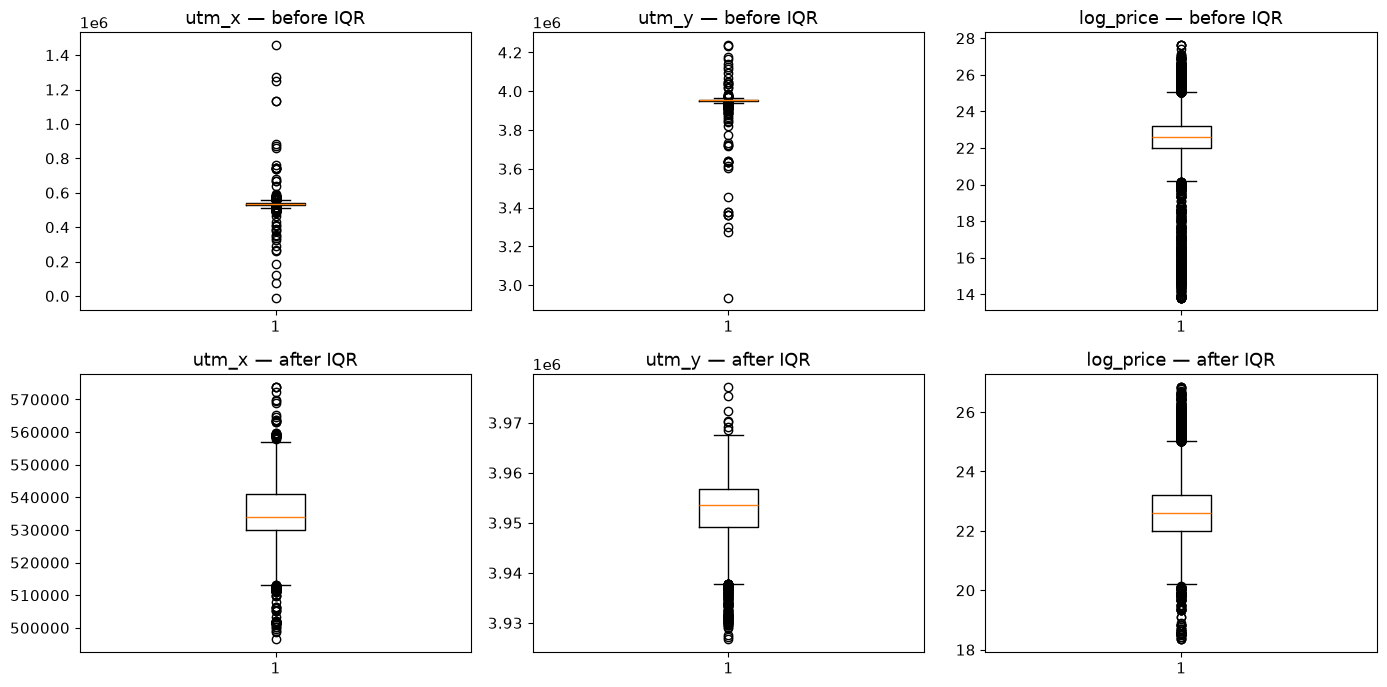

In [14]:
features = ["utm_x", "utm_y", "log_price"]

q1 = raw[features].quantile(0.25)
q3 = raw[features].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 3 * iqr, q3 + 3 * iqr

# حذف ردیف اگر حداقل یکی از سه ویژگی خارج از محدوده باشد
keep = (
    raw[features].ge(lower) & raw[features].le(upper)
).all(axis=1)

population = raw.loc[keep].copy()
clean = population.copy()

removed = (~keep).sum()
removed_pct = 100 * removed / len(raw) if len(raw) else 0.0
print(f"IQR removed: {removed:,} / {len(raw):,} ({removed_pct:.2f}%)")
print(f"Remaining rows: {len(clean):,}")

display(pd.DataFrame({"lower": lower, "upper": upper}))

if len(clean) < 30 or (clean[features].std() == 0).any():
    raise ValueError("Insufficient data or a constant feature after cleaning.")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for j, col in enumerate(features):
    axes[0, j].boxplot(raw[col].to_numpy())
    axes[0, j].set_title(f"{col} — before IQR")

    axes[1, j].boxplot(clean[col].to_numpy())
    axes[1, j].set_title(f"{col} — after IQR")

plt.tight_layout()
plt.show()

## سلول ۵ — تنظیمات و نمونه‌گیری قابل‌تکرار

پیش‌فرض **۱۰ نمونهٔ ۱۵٬۰۰۰تایی** است. داخل هر نمونه تکرار وجود ندارد؛ بین نمونه‌ها اشتراک طبیعی است.
دو بخش تصادفی جدا از جامعه کنار گذاشته می‌شوند: ۳٬۰۰۰ نقطهٔ `anchor` برای مقایسه و انتخاب،
و ۲٬۰۰۰ نقطهٔ `audit` برای بررسی پس از انتخاب. هیچ‌کدام وارد fit خوشه‌بندی نمونه‌ها نمی‌شوند.
همهٔ نمونه‌ها از یک مخزن مشترکِ باقی‌مانده گرفته می‌شوند و با **کل جامعهٔ پاک‌شده** مقایسه می‌شوند.
احتمال ورود به نمونه، پیش از تعیین مجموعه‌های کنارگذاشته‌شده، برای همهٔ ردیف‌ها برابر است.

`StandardScaler` یک‌بار روی کل جامعه fit می‌شود؛ این تحلیل با جامعهٔ موجود و معلوم سروکار دارد،
و هدف آزمون پیش‌بینی روی دادهٔ آینده نیست. مقیاس مشترک باعث می‌شود فاصله‌ها و eps قابل‌مقایسه باشند.

آستانه‌های زیر **معیار عملی اولیه** هستند، نه قانون آماری یا اثبات نمایندگی.
قبل از دیدن نتایج آن‌ها را تعیین کنید؛ برای نواحی یا قیمت‌های نادر به تفکیک دقیق‌تر نیاز دارید.

In [15]:
SAMPLE_SIZE = 15_000
SAMPLE_SEEDS = [101, 211, 307, 401, 503]#, 601, 701, 809, 907, 1009]
SPLIT_SEED = 20261002
ANCHOR_SIZE = 3_000
AUDIT_SIZE = 2_000

# حدود عملی برای مقایسهٔ نمونه با جامعه
REP_LIMITS = {"max_abs_smd": 0.10, "max_ks": 0.05,
              "max_wasserstein_sd": 0.10, "max_quantile_error_sd": 0.15,
              "corr_rmse": 0.05, "joint_tv": 0.10, "type_tv": 0.05}
JOINT_BINS = 5   # شبکهٔ ۵×۵×۵ روی مکان و log_price؛ نسبت‌های هر خانه مقایسه می‌شوند

# حدود عملی پذیرش پایداری و کیفیت؛ خروجی نامطمئن به‌عنوان نمونهٔ مناسب معرفی نمی‌شود
MIN_SUCCESS_RATE = 0.80
MIN_SUCCESSFUL_SAMPLES = 3
MIN_ANCHOR_COVERAGE = 0.50
MIN_PAIR_SHARED_ASSIGNED = 0.30
MIN_MEAN_JACCARD = 0.70
MIN_LOCAL_STABILITY = 0.70
MIN_THREE_RETENTION = 0.75
MIN_SILHOUETTE = 0.00
CONSENSUS_TOLERANCE = 0.03

SHORTLIST_SIZE = 3
VALIDATION_SILHOUETTE_SIZE = 2_000
VALIDATION_SEEDS = (42, 123, 2026)

if SAMPLE_SIZE != 15_000:
    warnings.warn("The requested sample size is 15,000; you changed SAMPLE_SIZE.")
if len(SAMPLE_SEEDS) < MIN_SUCCESSFUL_SAMPLES or len(set(SAMPLE_SEEDS)) != len(SAMPLE_SEEDS):
    raise ValueError("Use at least three distinct sampling seeds.")
if not population.index.is_unique:
    raise ValueError("Population row_id values must be unique.")
if len(population) < SAMPLE_SIZE + ANCHOR_SIZE + AUDIT_SIZE:
    raise ValueError("Not enough cleaned rows for a 15,000-row sample and both holdouts.")

population_sd = population[features].std(ddof=0)
if (population_sd <= 0).any() or not np.isfinite(population[features]).all().all():
    raise ValueError("The population contains constant or invalid model features.")

scaler = StandardScaler().fit(population[features])
scaled_columns = ["utm_x_scaled", "utm_y_scaled", "transformed_price_value"]
population_scaled = pd.DataFrame(scaler.transform(population[features]),
                                 columns=scaled_columns, index=population.index)
rng = np.random.default_rng(SPLIT_SEED)
split_ids = rng.permutation(population.index.to_numpy())
anchor_ids = np.sort(split_ids[:ANCHOR_SIZE])
audit_ids = np.sort(split_ids[ANCHOR_SIZE:ANCHOR_SIZE + AUDIT_SIZE])
pool_ids = np.sort(split_ids[ANCHOR_SIZE + AUDIT_SIZE:])
anchor_X = population_scaled.loc[anchor_ids].to_numpy()
audit_X = population_scaled.loc[audit_ids].to_numpy()

sample_indices = {
    seed: np.sort(np.random.default_rng(seed).choice(pool_ids, SAMPLE_SIZE, replace=False))
    for seed in SAMPLE_SEEDS
}
assert all(len(ids) == SAMPLE_SIZE and len(np.unique(ids)) == SAMPLE_SIZE
           for ids in sample_indices.values())
assert not np.intersect1d(pool_ids, np.r_[anchor_ids, audit_ids]).size
print(f"Cleaned population: {len(population):,}; sample pool: {len(pool_ids):,}")
print(f"Samples: {len(SAMPLE_SEEDS)} × {SAMPLE_SIZE:,}; anchor: {ANCHOR_SIZE:,}; audit: {AUDIT_SIZE:,}")
print(f"Expected overlap between two samples: {SAMPLE_SIZE**2 / len(pool_ids):,.0f} rows")

Cleaned population: 62,173; sample pool: 57,173
Samples: 5 × 15,000; anchor: 3,000; audit: 2,000
Expected overlap between two samples: 3,935 rows


## سلول ۶ — سنجش نمایندگی نمونه‌ها پیش از خوشه‌بندی

فقط میانگین کافی نیست. برای مکان، قیمت اصلی و log_price محاسبه می‌کنیم:

- `abs_smd`: اختلاف میانگین تقسیم بر انحراف معیار جامعه؛ کوچک‌تر بهتر.
- `KS`: بیشترین اختلاف دو توزیع تجمعی؛ کوچک‌تر بهتر. **p-value استفاده نمی‌شود**؛ نمونه زیرمجموعهٔ جامعه است.
- `wasserstein_sd`: فاصلهٔ توزیع‌ها در واحد انحراف معیار جامعه.
- `quantile_error_sd`: بیشترین اختلاف صدک‌های ۵، ۲۵، ۵۰، ۷۵ و ۹۵ در همین واحد.
- `corr_rmse`: اختلاف ساختار همبستگی سه ویژگی مدل.
- `joint_tv`: نصف مجموع اختلاف سهم خانه‌های شبکهٔ مشترک مکان×قیمت؛ توزیع مشترک را بررسی می‌کند.
- `type_tv`: اختلاف سهم آپارتمان/ویلا.

همهٔ حدود باید هم‌زمان برقرار باشند. `representativeness_score` از نزدیکی به این حدود ساخته می‌شود؛
امتیاز ۱ یعنی اختلاف صفر و امتیاز ۰ یعنی دست‌کم یکی از اختلاف‌ها به حد تعیین‌شده رسیده است.
شبکهٔ درشت و این چند ویژگی همهٔ شکل‌های سوگیری را آشکار نمی‌کنند؛ ویژگی‌های مهم دیگرِ موجود در CSV
مانند محله، متراژ و زمان آگهی را در صورت اهمیت به بررسی اضافه کنید.

In [16]:
diagnostic_features = features + ["price_value"]
quantile_levels = [0.05, 0.25, 0.50, 0.75, 0.95]
reference_sd = population[diagnostic_features].std(ddof=0)
reference_mean = population[diagnostic_features].mean()
reference_quantiles = population[diagnostic_features].quantile(quantile_levels)
reference_corr = population[features].corr().to_numpy()
type_levels = sorted(population.property_type.unique())
reference_types = (population.property_type.value_counts(normalize=True)
                   .reindex(type_levels, fill_value=0).to_numpy())
joint_edges = []
for feature in features:
    edges = np.unique(population[feature].quantile(np.linspace(0, 1, JOINT_BINS + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    joint_edges.append(edges)
reference_joint = np.histogramdd(population[features].to_numpy(), bins=joint_edges)[0]
reference_joint /= reference_joint.sum()

def representativeness(frame):
    rows = []
    for feature in diagnostic_features:
        sd = reference_sd[feature]
        if not np.isfinite(sd) or sd <= 0:
            raise ValueError(f"Constant or invalid diagnostic feature: {feature}")
        values = frame[feature].to_numpy()
        quantile_error = np.max(np.abs(
            np.quantile(values, quantile_levels) - reference_quantiles[feature].to_numpy()
        )) / sd
        rows.append({"feature": feature,
                     "population_mean": reference_mean[feature], "sample_mean": values.mean(),
                     "abs_smd": abs(values.mean() - reference_mean[feature]) / sd,
                     "ks": ks_2samp(values, population[feature], method="asymp").statistic,
                     "wasserstein_sd": wasserstein_distance(values, population[feature]) / sd,
                     "quantile_error_sd": quantile_error})
    detail = pd.DataFrame(rows)
    delta_corr = frame[features].corr().to_numpy() - reference_corr
    upper_corr = delta_corr[np.triu_indices(len(features), k=1)]
    joint = np.histogramdd(frame[features].to_numpy(), bins=joint_edges)[0]
    joint /= joint.sum()
    type_share = (frame.property_type.value_counts(normalize=True)
                  .reindex(type_levels, fill_value=0).to_numpy())
    metrics = {"max_abs_smd": detail.abs_smd.max(), "max_ks": detail.ks.max(),
               "max_wasserstein_sd": detail.wasserstein_sd.max(),
               "max_quantile_error_sd": detail.quantile_error_sd.max(),
               "corr_rmse": float(np.sqrt(np.mean(upper_corr**2))),
               "joint_tv": float(np.abs(joint - reference_joint).sum() / 2),
               "type_tv": float(np.abs(type_share - reference_types).sum() / 2)}
    ratios = np.array([metrics[k] / v for k, v in REP_LIMITS.items()])
    metrics["representative"] = bool(np.isfinite(ratios).all() and (ratios <= 1).all())
    metrics["representativeness_score"] = (float(1 - np.clip(ratios.max(), 0, 1))
                                          if np.isfinite(ratios).all() else 0.0)
    return metrics, detail

representation_rows, representation_details = [], {}
for seed, ids in sample_indices.items():
    stats, detail = representativeness(population.loc[ids])
    representation_rows.append({"seed": seed, "n_rows": len(ids), **stats})
    representation_details[seed] = detail
representation_table = pd.DataFrame(representation_rows).set_index("seed")
display(representation_table.round(4))

,n_rows,max_abs_smd,max_ks,max_wasserstein_sd,max_quantile_error_sd,corr_rmse,joint_tv,type_tv,representative,representativeness_score
seed,,,,,,,,,,
101,15000,0.0085,0.0050,0.0097,0.0576,0.0055,0.0276,0.0,True,0.6163
211,15000,0.0042,0.0053,0.0101,0.0674,0.0078,0.0253,0.0,True,0.5508
307,15000,0.0089,0.0085,0.0100,0.0291,0.0043,0.0279,0.0,True,0.7207
401,15000,0.0144,0.0054,0.0167,0.0291,0.0103,0.0271,0.0,True,0.7289
503,15000,0.0104,0.0082,0.0111,0.0618,0.0056,0.0304,0.0,True,0.5882


## سلول ۷ — تعریف جست‌وجوی DBSCAN و کیفیت هر مدل

منطق اصلی جست‌وجوی نسخهٔ قبلی حفظ شده است: شعاع‌های k-distance، تغییر محلی و گسترش جست‌وجو؛
این سلول فقط توابع را تعریف می‌کند و سلول ۹ آن‌ها را برای هر نمونه اجرا می‌کند.
بودجهٔ تقریبی همسایگی‌ها کمتر شده تا اجرای چند نمونه حافظه را پر نکند؛ این برآورد تضمین مصرف حافظه نیست.

هدف **سه خوشه** مطابق نوت‌بوک قبلی حفظ شده است، نه به‌عنوان کشف تعداد طبیعی خوشه‌ها.
پذیرش اولیه: سه خوشه، نویز حداکثر ۴۰٪، کوچک‌ترین خوشه حداقل ۱٪ کل نمونه و
بزرگ‌ترین خوشه حداکثر ۹۵٪ نقاطِ دارای خوشه. Silhouette بدون نویز برآورد می‌شود؛
به‌تنهایی معیار مناسب‌بودن نمونه نیست و ممکن است خوشه‌های غیرمحدب DBSCAN را کم‌امتیاز کند.

پارامترها برای اندازهٔ **۱۵٬۰۰۰** جست‌وجو می‌شوند. پارامتر بهینهٔ یک مدل ۶۰٬۰۰۰تایی را
بدون بررسی به نمونه منتقل نکنید؛ با کاهش حجم داده، شمار همسایه‌ها و تراکم مشاهده‌شده تغییر می‌کند.

In [17]:
from sklearn.metrics import silhouette_samples
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import KDTree
import hashlib
# True: محاسبه Silhouette برای تمام مدل‌های دارای حداقل دو خوشه
# False: محاسبه فقط برای مدل‌های سه‌کلاستری، مانند نسخه قبلی
COMPUTE_ALL_SILHOUETTES = False
# تنظیمات جست‌وجو
# min_samples_list = [70, 100, 150, 500, 900, 1400 , 1800] # , 2200 , 2700]
min_samples_list = [5, 10, 20, 40, 70, 100, 150, 200, 250]
LOCAL_CHANGE = 0.20
EXPANSION_CHANGE = 0.30
MIN_SAMPLES_MIN = 1
KNEE_MULTIPLIERS = np.round(np.linspace(0.1, 1.5, 8) , 4)
EXPANSION_QUANTILES = [0.35, 0.70, 0.95]
EXPANSION_SCALES = [1.0]  # سه صدک بدون ضرایب اضافی
MAX_EXPANSION_ROUNDS = 20
# محدودیت EPS_MAX فقط برای جست‌وجوی اولیه و محلیِ آن است.
EPS_MAX = 5
MAX_NOISE = 0.40 #0.40
MIN_CLUSTER_SHARE = 0.01 #0.1
MAX_LARGEST_ASSIGNED_SHARE = 0.95 #0.95
PROBE_SIZE = 1500
NEIGHBOR_BATCH_BYTES = 128 * 1024**2
DBSCAN_MEMORY_BUDGET = 8 * 1024**3
records, label_cache, tested, skipped = [], {}, set(), set()
knee_eps, distance_curves, radius_budget_cache = {}, {}, {}
search_fingerprint = None
search_complete = False
neighbor_model = radius_tree = None
def reset_if_data_changed():
    global search_fingerprint, search_complete, neighbor_model, radius_tree
    signature = hashlib.sha256(
        np.ascontiguousarray(X, dtype=np.float64).tobytes()
    ).hexdigest()
    if signature != search_fingerprint:
        records.clear()
        label_cache.clear()
        tested.clear()
        skipped.clear()
        knee_eps.clear()
        distance_curves.clear()
        radius_budget_cache.clear()
        search_complete = False
        neighbor_model = radius_tree = None
        search_fingerprint = signature
        print(
            f"Search data: shape={X.shape}, fingerprint={signature[:16]}",
            flush=True
        )
    return signature

def quality_mask(frame):
    """پذیرش نامزد نیازمند برقراری هر چهار شرط است."""
    return (
        (frame.n_clusters == 3)
        & (frame.noise_ratio <= MAX_NOISE)
        & (frame.smallest_share >= MIN_CLUSTER_SHARE)
        & (
            frame.largest_assigned_share
            <= MAX_LARGEST_ASSIGNED_SHARE
        )
    )

def acceptable_candidates():
    table = pd.DataFrame(records)
    return table.loc[quality_mask(table)].copy() if len(table) else table

def evaluate(labels, sample_size=2000, seeds=(42,), compute_score=True):
    assigned = labels >= 0
    ids, counts = np.unique(labels[assigned], return_counts=True)
    shares = counts / counts.sum() if len(counts) else np.array([])
    balance = (
        -np.sum(shares * np.log(shares)) / np.log(len(ids))
        if len(ids) > 1 else 0.0
    )
    scores, worst_scores = [], []
    if compute_score and 2 <= len(ids) < assigned.sum():
        all_idx = np.flatnonzero(assigned)
        for seed in seeds:
            rng = np.random.default_rng(seed)
            if len(all_idx) <= sample_size:
                idx = all_idx
            else:
                required = np.concatenate([
                    rng.choice(
                        np.flatnonzero(labels == k),
                        min(2, count),
                        replace=False
                    )
                    for k, count in zip(ids, counts)
                ])
                pool = np.setdiff1d(all_idx, required)
                extra = max(0, sample_size - len(required))
                idx = np.r_[
                    required,
                    rng.choice(pool, extra, replace=False)
                ]
            values = silhouette_samples(X[idx], labels[idx])
            per_cluster = np.array([
                values[labels[idx] == k].mean()
                for k in ids
            ])
            scores.append(float(per_cluster @ shares))
            worst_scores.append(float(per_cluster.min()))

    return {
        "n_clusters": len(ids),
        "noise_ratio": float((~assigned).mean()),
        "smallest_share": (
            float(counts.min() / len(X)) if len(counts) else 0.0
        ),
        "largest_assigned_share": (
            float(shares.max()) if len(shares) else 0.0
        ),
        "balance": float(balance),
        "silhouette": float(np.mean(scores)) if scores else np.nan,
        "silhouette_std": float(np.std(scores)) if scores else np.nan,
        "worst_cluster_silhouette": (
            float(np.mean(worst_scores)) if worst_scores else np.nan
        )
    }

def fit_labels(eps, m):
    reset_if_data_changed()
    key = (round(float(eps), 6), int(m))
    if key not in label_cache:
        model = DBSCAN(
            eps=key[0],
            min_samples=key[1],
            algorithm="kd_tree",
            n_jobs=-1
        )
        label_cache[key] = model.fit_predict(X).astype(np.int32)
    return label_cache[key]

def radius_is_safe(eps):
    global radius_tree
    if eps not in radius_budget_cache:
        if radius_tree is None:
            radius_tree = KDTree(X)
        edge_count = radius_tree.query_radius(
            X, r=eps, count_only=True
        ).sum(dtype=np.int64)
        radius_budget_cache[eps] = (
            int(edge_count) * 24 <= DBSCAN_MEMORY_BUDGET
        )
    return radius_budget_cache[eps]

def run_trial(eps, m, stage, eps_limit=np.inf):
    reset_if_data_changed()
    key = (round(float(eps), 6), int(m))
    def report_skip(reason):
        print(
            f"[SKIP] stage={stage}, min_samples={key[1]}, "
            f"eps={key[0]:.6f} | {reason}",
            flush=True
        )

    if key in tested:
        report_skip("این ترکیب قبلاً اجرا شده؛ اجرای تکراری حذف شد.")
        return
    if key in skipped:
        report_skip("این ترکیب قبلاً به دلیل عبور از بودجه حافظه رد شده است.")
        return
    if not np.isfinite(key[0]):
        report_skip("eps نامعتبر است: مقدار NaN یا بی‌نهایت.")
        return
    if key[0] <= 0:
        report_skip("eps باید بزرگ‌تر از صفر باشد.")
        return
    if key[0] > eps_limit:
        report_skip(
            f"eps={key[0]:.6f} از سقف مجاز eps_limit={eps_limit:.6f} "
            "در این مرحله بیشتر است."
        )
        return
    if not MIN_SAMPLES_MIN <= key[1] <= len(X):
        report_skip(
            f"min_samples خارج از بازه مجاز "
            f"[{MIN_SAMPLES_MIN}, {len(X)}] است."
        )
        return
    if not radius_is_safe(key[0]):
        skipped.add(key)
        report_skip(
            "برآورد حافظه همسایگی‌ها از بودجه "
            f"DBSCAN_MEMORY_BUDGET={DBSCAN_MEMORY_BUDGET / 1024**3:.2f} GiB "
            "بیشتر است."
        )
        return
    trial = fit_labels(*key)
    stats = evaluate(trial, compute_score=False)
    if (
        stats["n_clusters"] == 3
        or (
            COMPUTE_ALL_SILHOUETTES
            and stats["n_clusters"] >= 2
        )
    ):
        stats = evaluate(trial)
    records.append({
        "eps": key[0],
        "min_samples": key[1],
        "stage": stage,
        **stats
    })
    tested.add(key)

def kth_distances(m, query):
    """محاسبه فاصله همسایه‌ها به‌صورت دسته‌ای برای کنترل حافظه."""
    global neighbor_model
    if neighbor_model is None:
        neighbor_model = NearestNeighbors(
            algorithm="kd_tree",
            n_jobs=-1
        ).fit(X)
    # برای m=1، فاصله خود نقطه صفر است؛ شعاع از نزدیک‌ترین نقطه دیگر.
    k = min(len(X), max(2, int(m)))
    batch_size = max(1, NEIGHBOR_BATCH_BYTES // (16 * k))
    distances = np.empty(len(query), dtype=float)
    for start in range(0, len(query), batch_size):
        stop = min(start + batch_size, len(query))
        batch = neighbor_model.kneighbors(
            query[start:stop],
            n_neighbors=k
        )[0]
        distances[start:stop] = batch[:, k - 1]

    return distances

def knee_radii(m):
    if m not in knee_eps:
        sorted_dist = np.sort(kth_distances(m, X))
        loc = (KneeLocator(np.arange(len(X)), sorted_dist,
                           curve="convex", direction="increasing")
               if KneeLocator is not None else None)
        eps = (
            float(sorted_dist[int(loc.elbow)])
            if loc is not None and loc.elbow is not None else 0.0
        )
        if eps <= 0:
            positive = sorted_dist[sorted_dist > 0]
            eps = (
                float(np.quantile(positive, 0.90))
                if len(positive) else 0.0
            )
            print(
                f"min_samples={m}: no positive knee; "
                "using positive 90th percentile."
            )
        knee_eps[m] = eps
        distance_curves[m] = sorted_dist
    return np.unique(
        np.round(knee_eps[m] * KNEE_MULTIPLIERS, 6)
    )

def expansion_radii(m):
    probe_idx = np.unique(
        np.linspace(
            0,
            len(X) - 1,
            min(PROBE_SIZE, len(X))
        ).astype(int)
    )
    positive = kth_distances(m, X[probe_idx])
    positive = positive[positive > 0]
    if not len(positive):
        return np.array([], dtype=float)
    base = np.quantile(positive, EXPANSION_QUANTILES)
    return np.unique(
        np.round(
            np.concatenate([
                base * scale
                for scale in EXPANSION_SCALES
            ]),
            6
        )
    )

def search_at(m, radii, stage, eps_limit=np.inf):
    """خروجی تابع فقط مشخص می‌کند آیا مدل سه‌کلاستری پیدا شده است."""
    for eps in radii:
        run_trial(eps, m, stage, eps_limit)

    table = pd.DataFrame(records)
    if table.empty:
        has_three = has_acceptable = False
    else:
        current = table.loc[
            (table.min_samples == m)
            & table.eps.isin(np.round(radii, 6))
            & (table.eps <= eps_limit)
        ]
        # فعال‌شدن جست‌وجوی محلی فقط به سه خوشه وابسته است.
        has_three = bool((current.n_clusters == 3).any())
        # این مقدار صرفاً برای گزارش وضعیت کیفیت است.
        has_acceptable = bool(quality_mask(current).any())
    print(
        f"{stage}: min_samples={m}, fits={len(tested)}, "
        f"three_clusters={has_three}, acceptable={has_acceptable}",
        flush=True
    )
    return has_three

def refine_successes(parents, eps_limit, use_own_quantiles=False):
    """یک مرحله محلی؛ شعاع‌های فرزندان در گسترش از صدک‌های خودشان."""
    for parent_m, parent_radii in parents:
        local_values = np.unique(np.rint(
            parent_m * np.array([1 - LOCAL_CHANGE, 1 + LOCAL_CHANGE])
        ).astype(int))
        for m in local_values:
            m = int(m)
            if MIN_SAMPLES_MIN <= m <= len(X):
                radii = (
                    expansion_radii(m)
                    if use_own_quantiles else parent_radii
                )
                search_at(m, radii, "local-refinement", eps_limit)

def ensure_three_candidates():
    global search_complete
    reset_if_data_changed()
    if search_complete and not acceptable_candidates().empty:
        return pd.DataFrame(records)
    search_complete = False
    if len(X) < 2:
        raise ValueError("At least two cleaned rows are required.")
    if not 0 < LOCAL_CHANGE < 1 or not 0 < EXPANSION_CHANGE < 1:
        raise ValueError(
            "LOCAL_CHANGE and EXPANSION_CHANGE must be between 0 and 1."
        )
    if not MIN_SAMPLES_MIN >= 1:
        raise ValueError("MIN_SAMPLES_MIN must be at least 1.")
    if (
        MAX_EXPANSION_ROUNDS < 1
        or PROBE_SIZE < 1
        or not len(KNEE_MULTIPLIERS)
        or not len(EXPANSION_SCALES)
        or np.any(np.asarray(KNEE_MULTIPLIERS) <= 0)
        or np.any(np.asarray(EXPANSION_SCALES) <= 0)
    ):
        raise ValueError(
            "Search counts and radius multipliers must be positive."
        )
    initial = sorted({
        int(m)
        for m in min_samples_list
        if MIN_SAMPLES_MIN <= int(m) <= len(X)
    })
    if not initial:
        raise ValueError(
            "No initial min_samples value is valid for the current X."
        )
    # مرحله اول: بررسی تمام مقادیر اولیه
    parents = []
    for m in initial:
        radii = knee_radii(m)
        if search_at(m, radii, "initial-knee", EPS_MAX):
            parents.append((m, radii))

    # حتی والد فاقد کیفیت، با داشتن سه خوشه، محلی بررسی می‌شود.
    if parents:
        refine_successes(parents, EPS_MAX)
    # تنها وجود نامزد دارای هر چهار شرط مانع گسترش می‌شود.
    if acceptable_candidates().empty:
        lower, upper = initial[0], initial[-1]
        for round_id in range(1, MAX_EXPANSION_ROUNDS + 1):
            new_lower = max(
                MIN_SAMPLES_MIN,
                int(round(lower * (1 - EXPANSION_CHANGE)))
            )
            new_upper = min(
                len(X),
                int(round(upper * (1 + EXPANSION_CHANGE)))
            )
            # جلوگیری از ثابت‌ماندن مرزها به دلیل گردکردن
            if new_lower == lower and lower > MIN_SAMPLES_MIN:
                new_lower = lower - 1
            if new_upper == upper and upper < len(X):
                new_upper = upper + 1
            next_values = sorted({
                m
                for m, old in [
                    (new_lower, lower),
                    (new_upper, upper)
                ]
                if m != old
            })
            # هر دو مرز به حد معتبر خود رسیده‌اند.
            if not next_values:
                break
            lower, upper = new_lower, new_upper
            parents = []
            print(
                f"Expansion round {round_id}: "
                f"min_samples={next_values}",
                flush=True
            )
            for m in next_values:
                radii = expansion_radii(m)
                if search_at(m, radii, "expanded-30pct"):
                    parents.append((m, radii))

            # جست‌وجوی محلی برای تمام والدهای سه‌کلاستری این دور
            if parents:
                refine_successes(parents, np.inf, use_own_quantiles=True)
            # سه خوشه به‌تنهایی باعث توقف نمی‌شود.
            if not acceptable_candidates().empty:
                break

    table = pd.DataFrame(records)
    if acceptable_candidates().empty:
        if len(table):
            display(
                table.groupby("min_samples").agg(
                    tested_eps=("eps", "size"),
                    min_eps=("eps", "min"),
                    max_eps=("eps", "max"),
                    min_clusters=("n_clusters", "min"),
                    max_clusters=("n_clusters", "max")
                )
            )
        raise RuntimeError(
            "No three-cluster model meeting all quality conditions was found. "
            "Expansion reached its round/boundary limit; some dense settings "
            "may have been skipped for memory safety. Adjust the search controls."
        )
    search_complete = True
    return table

## سلول ۸ — توابع مقایسهٔ خوشه‌ها و انتخاب مدل هر نمونه

شناسهٔ خوشه‌ها قابل‌مقایسه نیست؛ `ARI` به جابه‌جایی شماره‌ها حساس نیست و Jaccard با
تطبیق بهینهٔ خوشه‌ها محاسبه می‌شود. دو نمای مقایسه داریم:

1. **اشتراک ردیف‌های آموزش**: برچسب‌های واقعی DBSCAN روی شناسه‌های یکسان؛ مستقل از تقریب انتساب.
2. **anchor مشترک و خارج از آموزش**: به نزدیک‌ترین نقطهٔ core، فقط در فاصلهٔ حداکثر eps، برچسب می‌دهیم؛
   اگر نقطه در شعاع coreهای بیش از یک خوشه باشد، آن را مبهم و با برچسب `-2` ثبت می‌کنیم و از مقایسهٔ آن زوج حذف می‌کنیم.
   این یک **قاعدهٔ تقریبی برای مقایسه** است؛ DBSCAN در sklearn متد `predict` ندارد و این کار fit روی anchor یا کل داده نیست.

`ARI_all` نویز را هم شامل می‌شود؛ اگر نویز زیاد باشد می‌تواند گمراه‌کننده باشد.
در کنار آن `ARI_both_assigned`، Jaccard بدون خوشهٔ نویز، توافق نویز و سهم نقاطِ دارای خوشه در هر دو مدل گزارش می‌شوند.
Jaccard، تغییر عضو خوشه به نویز را هم جریمه می‌کند؛ در صورت نبود خوشه، مقدارش صفر است.

انتخاب پارامتر هر نمونه با کیفیت، نویز، توازن و حساسیت به تغییر ±۵٪ eps/min_samples انجام می‌شود.
برای min_samples کوچک، اگر گردکردن همان مقدار را بدهد، نزدیک‌ترین عدد صحیح متفاوت بررسی می‌شود؛
تغییر واقعی ممکن است بیش از ۵٪ باشد و مقادیر دقیق در جدول حساسیت ثبت می‌شوند.
این معیارها به‌صورت اکتشافی استفاده می‌شوند و شاخص اطمینان آماری نیستند.

In [18]:
def selection_score(frame, include_stability=False):
    conservative = (frame.silhouette - frame.silhouette_std).clip(-1, 1)
    score = (0.45 * (conservative + 1) / 2
             + 0.20 * (1 - frame.noise_ratio) + 0.20 * frame.balance)
    if include_stability:
        score = score + 0.15 * frame.stability
    return score

def cluster_jaccard(reference, trial):
    ref_ids = np.unique(reference[reference >= 0])
    trial_ids = np.unique(trial[trial >= 0])
    if not len(ref_ids) or not len(trial_ids):
        return 0.0
    overlaps = np.zeros((len(ref_ids), len(trial_ids)))
    for i, a in enumerate(ref_ids):
        for j, b in enumerate(trial_ids):
            left, right = reference == a, trial == b
            overlaps[i, j] = np.count_nonzero(left & right) / np.count_nonzero(left | right)
    rows, cols = linear_sum_assignment(-overlaps)
    return float(overlaps[rows, cols].sum() / max(len(ref_ids), len(trial_ids)))

def sensitivity(eps, m, reference):
    checks = []
    settings = [(eps * f, m) for f in [0.95, 1.05]]
    for factor in [0.95, 1.05]:
        trial_m = max(1, min(len(X), int(round(m * factor))))
        # At small m, +/-5% rounds back to m; use the nearest distinct integer.
        if trial_m == m:
            trial_m = max(1, min(len(X), m + (-1 if factor < 1 else 1)))
        if trial_m != m:
            settings.append((eps, trial_m))
    settings = list(dict.fromkeys((round(float(e), 6), int(k)) for e, k in settings))
    for trial_eps, trial_m in settings:
        if not radius_is_safe(round(float(trial_eps), 6)):
            checks.append({"eps": trial_eps, "min_samples": trial_m,
                           "n_clusters": np.nan, "noise_ratio": np.nan,
                           "ARI_to_selected": np.nan, "cluster_jaccard": 0.0,
                           "skipped_memory": True})
            continue
        trial = fit_labels(trial_eps, trial_m)
        checks.append({"eps": trial_eps, "min_samples": trial_m,
                       **evaluate(trial, compute_score=False),
                       "ARI_to_selected": adjusted_rand_score(reference, trial),
                       "cluster_jaccard": cluster_jaccard(reference, trial)})
    return pd.DataFrame(checks)


def select_model_for_current_sample():
    results = ensure_three_candidates()
    candidates = results.loc[quality_mask(results)].copy()
    candidates["screen_score"] = selection_score(candidates)
    shortlist = candidates.sort_values(["screen_score", "eps", "min_samples"],
                                       ascending=[False, True, True]).head(SHORTLIST_SIZE)
    evaluated, tables = [], {}
    for row in shortlist.itertuples():
        candidate_labels = fit_labels(row.eps, row.min_samples)
        stats = evaluate(candidate_labels, sample_size=VALIDATION_SILHOUETTE_SIZE,
                         seeds=VALIDATION_SEEDS)
        checks = sensitivity(row.eps, row.min_samples, candidate_labels)
        tables[(float(row.eps), int(row.min_samples))] = checks
        evaluated.append({"eps": float(row.eps), "min_samples": int(row.min_samples), **stats,
                          "stability": checks.cluster_jaccard.mean(),
                          "three_cluster_retention": (checks.n_clusters == 3).mean()})
    ranked = pd.DataFrame(evaluated)
    ranked["selection_score"] = selection_score(ranked, include_stability=True)
    ranked = ranked.sort_values(["selection_score", "eps", "min_samples"],
                                ascending=[False, True, True])
    # Recheck quality on the independently rescored shortlist; never use an invalid fallback.
    ranked = ranked.loc[quality_mask(ranked)]
    if ranked.empty:
        raise RuntimeError("No valid shortlisted model remains.")
    best = ranked.iloc[0]
    return best, ranked, tables

def project_to_core(model, points):
    """Approximate labels for held-out points; -1=no nearby core, -2=ambiguous."""
    core_ids = model.core_sample_indices_
    output = np.full(len(points), -1, dtype=np.int32)
    if not len(core_ids):
        return output
    core_labels = model.labels_[core_ids]
    nearest_distance = np.full(len(points), np.inf)
    touched_clusters = np.zeros(len(points), dtype=int)
    for cluster_id in np.unique(core_labels):
        cluster_core = model.components_[core_labels == cluster_id]
        tree = KDTree(cluster_core)
        dist = tree.query(points, k=1, return_distance=True)[0][:, 0]
        within = dist <= model.eps
        touched_clusters += within
        improve = within & (dist < nearest_distance)
        output[improve] = int(cluster_id)
        nearest_distance[improve] = dist[improve]
    output[touched_clusters > 1] = -2
    return output

def partition_metrics(left, right):
    left, right = np.asarray(left), np.asarray(right)
    if left.shape != right.shape:
        raise ValueError("Compare labels for exactly the same observations and order.")
    total = len(left)
    valid = (left != -2) & (right != -2)
    a, b = left[valid], right[valid]
    both = (a >= 0) & (b >= 0)
    # Conditional ARI is meaningful here only when each partition has >=2 clusters.
    ari_assigned = (adjusted_rand_score(a[both], b[both])
                    if both.sum() >= 3 and len(np.unique(a[both])) >= 2
                    and len(np.unique(b[both])) >= 2 else np.nan)
    noise_union = (a == -1) | (b == -1)
    noise_jaccard = (np.count_nonzero((a == -1) & (b == -1)) / noise_union.sum()
                     if noise_union.any() else np.nan)
    return {"n_points": total, "n_compared": len(a), "n_both_assigned": int(both.sum()),
            "compared_fraction": float(valid.mean()) if total else 0.0,
            "both_assigned_fraction": float(both.sum() / total) if total else 0.0,
            "ARI_all": adjusted_rand_score(a, b) if len(a) >= 3 else np.nan,
            "ARI_both_assigned": ari_assigned,
            "cluster_jaccard": cluster_jaccard(a, b) if len(a) else 0.0,
            "noise_jaccard": noise_jaccard,
            "noise_status_agreement": float(((a == -1) == (b == -1)).mean()) if len(a) else np.nan}

def compare_runs(runs, anchor_key="anchor_labels", label_key="labels", ids_key="ids"):
    pairs = []
    for left_seed, right_seed in combinations(sorted(runs), 2):
        left, right = runs[left_seed], runs[right_seed]
        shared, li, ri = np.intersect1d(left[ids_key], right[ids_key], return_indices=True)
        anchor = partition_metrics(left[anchor_key], right[anchor_key])
        overlap = partition_metrics(left[label_key][li], right[label_key][ri])
        pairs.append({"left_seed": left_seed, "right_seed": right_seed,
                      **{"anchor_" + k: v for k, v in anchor.items()},
                      **{"overlap_" + k: v for k, v in overlap.items()}})
    return pd.DataFrame(pairs)

def similarity_matrix(pair_table, value, seeds):
    matrix = pd.DataFrame(
        np.nan, index=seeds, columns=seeds, dtype=float
    )

    # تغییر مستقیم از طریق pandas
    for seed in seeds:
        matrix.at[seed, seed] = 1.0

    for row in pair_table.to_dict("records"):
        left = row["left_seed"]
        right = row["right_seed"]
        matrix.at[left, right] = row[value]
        matrix.at[right, left] = row[value]

    return matrix

def mean_to_others(matrix):
    masked = matrix.copy()

    # حذف شباهت هر نمونه به خودش از میانگین
    for i in range(len(masked)):
        masked.iat[i, i] = np.nan

    return masked.mean(axis=1)

## سلول ۹ — اجرای جست‌وجو روی همهٔ نمونه‌ها

برای هر seed، دقیقاً همان رویه و حدود کیفیت اجرا می‌شوند. شکست‌ها حذف یا پنهان نمی‌شوند؛
در جدول وضعیت و نرخ موفقیت ثبت می‌شوند. فقط بهترین مدل هر نمونه و داده‌های لازم نگه داشته می‌شوند؛
حافظهٔ جست‌وجوی هر نمونه برای نمونهٔ بعدی پاک می‌شود. گزارش کامل جست‌وجو در `run_logs` موجود است.
این بخش از اجرای یک نمونه زمان بیشتری می‌برد؛ زمان واقعی به تراکم داده و تعداد پارامترهای بررسی‌شده وابسته است.

In [19]:
runs, run_logs, status_rows = {}, {}, []
for seed in SAMPLE_SEEDS:
    print(f"Starting sample seed={seed} ({SAMPLE_SIZE:,} rows)...", flush=True)
    ids = sample_indices[seed]
    clean = population.loc[ids].copy()
    model_data = population_scaled.loc[ids].copy()
    X = model_data.to_numpy()
    # Reset caches even if the cell is rerun; no stale results from another sample.
    search_fingerprint = None
    reset_if_data_changed()
    captured = io.StringIO()
    try:
        with contextlib.redirect_stdout(captured):
            best, ranked, tables = select_model_for_current_sample()
        model = DBSCAN(eps=float(best.eps), min_samples=int(best.min_samples),
                       algorithm="kd_tree", n_jobs=-1).fit(X)
        anchor_labels = project_to_core(model, anchor_X)
        anchor_coverage = float((anchor_labels >= 0).mean())
        runs[seed] = {"ids": ids.copy(), "labels": model.labels_.astype(np.int32),
                      "core_points": model.components_.copy(),
                      "core_labels": model.labels_[model.core_sample_indices_].copy(),
                      "best": best.to_dict(), "ranked": ranked.copy(),
                      "checks": tables[(float(best.eps), int(best.min_samples))].copy(),
                      "search_results": pd.DataFrame(records).copy(),
                      "anchor_labels": anchor_labels,
                      "anchor_coverage": anchor_coverage,
                      "anchor_noise_ratio": float((anchor_labels == -1).mean()),
                      "anchor_ambiguity_ratio": float((anchor_labels == -2).mean())}
        status_rows.append({"seed": seed, "status": "success", "reason": "",
                            "tested_settings": len(records), "skipped_dense": len(skipped)})
        print(f"  Done: eps={best.eps:.4f}, min_samples={int(best.min_samples)}, "
              f"silhouette={best.silhouette:.3f}, anchor coverage={anchor_coverage:.1%}", flush=True)
    except (RuntimeError, ValueError, MemoryError) as exc:
        status_rows.append({"seed": seed, "status": "failed", "reason": str(exc),
                            "tested_settings": len(records), "skipped_dense": len(skipped)})
        print(f"  Failed: {exc}", flush=True)
    finally:
        run_logs[seed] = captured.getvalue()
        label_cache.clear()
        radius_budget_cache.clear()
        neighbor_model = radius_tree = None

sample_status = pd.DataFrame(status_rows).set_index("seed")
display(sample_status)
print(f"Successful samples: {len(runs)}/{len(SAMPLE_SEEDS)}")
if len(runs) < MIN_SUCCESSFUL_SAMPLES:
    raise RuntimeError("Too few successful samples to compare. Inspect sample_status and run_logs.")

Starting sample seed=101 (15,000 rows)...
Search data: shape=(15000, 3), fingerprint=d144a2482208f851
  Done: eps=0.4441, min_samples=325, silhouette=0.345, anchor coverage=62.6%
Starting sample seed=211 (15,000 rows)...
Search data: shape=(15000, 3), fingerprint=cc8354b6f6cc6e80
  Done: eps=0.4772, min_samples=390, silhouette=0.323, anchor coverage=64.4%
Starting sample seed=307 (15,000 rows)...
Search data: shape=(15000, 3), fingerprint=cad9958b0c020bff
  Done: eps=0.4785, min_samples=390, silhouette=0.307, anchor coverage=63.5%
Starting sample seed=401 (15,000 rows)...
Search data: shape=(15000, 3), fingerprint=1f4c576e60271768
  Done: eps=0.4657, min_samples=390, silhouette=0.321, anchor coverage=60.5%
Starting sample seed=503 (15,000 rows)...
Search data: shape=(15000, 3), fingerprint=721be7995ec846a0
  Done: eps=0.3457, min_samples=100, silhouette=0.170, anchor coverage=81.4%


,status,reason,tested_settings,skipped_dense
seed,,,,
101,success,,84,0
211,success,,148,0
307,success,,116,0
401,success,,116,0
503,success,,136,0


Successful samples: 5/5


## سلول ۱۰ — مقایسهٔ نتایجِ تنظیم‌شده و کنترل با پارامتر ثابت

مقایسهٔ اول، بهترین مدل هر نمونه را می‌سنجد: اثر نمونه‌گیری **به‌همراه** اثر تنظیم پارامترها.
برای جداکردن اثر نمونه‌گیری، یک مدل «مرکزی» از بین پارامترهای منتخب انتخاب می‌شود:
زوج واقعی eps/min_samples نزدیک‌تر به میانهٔ پارامترهای منتخب (در فضای لگاریتمی)،
سپس **همان زوج، بدون تغییر** روی همهٔ نمونه‌ها fit می‌شود؛ این انتخاب از برچسب‌های anchor استفاده نمی‌کند.
این کنترل تعداد خوشه‌ها را مجبور به سه نمی‌کند؛ تعداد طبیعی حاصل از پارامتر ثابت گزارش می‌شود.
نرخ حفظ سه خوشه و توافق روی اشتراک آموزش و anchor نشان می‌دهند نتیجه تا چه حد به نمونه وابسته است.

برای انتخاب، شباهت هر نمونه هم به تمام اجراهای موفق و هم به اکثریت نمونه‌های نمایندهٔ موفق گزارش می‌شود.
نمونه‌های دارای خطای fit در نرخ موفقیت کل دخیل‌اند؛ نمی‌توان فقط چند موفقیت اتفاقی را انتخاب کرد.

,left_seed,right_seed,anchor_n_points,anchor_n_compared,anchor_n_both_assigned,anchor_compared_fraction,anchor_both_assigned_fraction,anchor_ARI_all,anchor_ARI_both_assigned,anchor_cluster_jaccard,...,overlap_n_points,overlap_n_compared,overlap_n_both_assigned,overlap_compared_fraction,overlap_both_assigned_fraction,overlap_ARI_all,overlap_ARI_both_assigned,overlap_cluster_jaccard,overlap_noise_jaccard,overlap_noise_status_agreement
0,101,211,3000,2995,1841,0.9983,0.6137,0.8906,0.9956,0.8925,...,3912,3912,2315,1.0,0.5918,0.8907,0.9974,0.9083,0.9004,0.9594
1,101,307,3000,2988,1830,0.9960,0.6100,0.9024,1.0000,0.9148,...,3916,3916,2348,1.0,0.5996,0.8920,0.9876,0.9023,0.8992,0.9597
2,101,401,3000,2998,1791,0.9993,0.5970,0.9144,0.9979,0.8868,...,3958,3958,2369,1.0,0.5985,0.9089,0.9887,0.8813,0.9075,0.9629
3,101,503,3000,2998,1860,0.9993,0.6200,0.1470,-0.0030,0.1846,...,3958,3958,2428,1.0,0.6134,0.1468,-0.0035,0.1855,0.4680,0.7943
4,211,307,3000,2985,1885,0.9950,0.6283,0.9526,0.9970,0.9420,...,3981,3981,2513,1.0,0.6312,0.9505,0.9991,0.9469,0.9462,0.9802
5,211,401,3000,2994,1808,0.9980,0.6027,0.8930,1.0000,0.8824,...,4026,4026,2428,1.0,0.6031,0.8909,0.9801,0.8717,0.8961,0.9588
6,211,503,3000,2994,1891,0.9980,0.6303,0.1511,-0.0044,0.1866,...,3899,3899,2417,1.0,0.6199,0.1516,-0.0052,0.1860,0.4690,0.7982
7,307,401,3000,2988,1801,0.9960,0.6003,0.9092,1.0000,0.8955,...,3916,3916,2371,1.0,0.6055,0.9220,0.9859,0.9087,0.9275,0.9714
8,307,503,3000,2987,1871,0.9957,0.6237,0.1537,-0.0030,0.1880,...,3912,3912,2459,1.0,0.6286,0.1622,-0.0047,0.1927,0.4591,0.7991
9,401,503,3000,2997,1790,0.9990,0.5967,0.1275,-0.0033,0.1846,...,3924,3924,2354,1.0,0.5999,0.1240,-0.0056,0.1852,0.4280,0.7712


Fixed-parameter control: eps=0.465673, min_samples=390


,status,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette,anchor_coverage
seed,,,,,,,,,,
101,success,3,0.400400,0.058467,0.738159,0.680720,NaN,NaN,NaN,0.608667
211,success,3,0.396133,0.064200,0.732612,0.692088,NaN,NaN,NaN,0.614667
307,success,3,0.401667,0.059600,0.735822,0.684889,NaN,NaN,NaN,0.605667
401,success,3,0.397133,0.050867,0.743227,0.666512,NaN,NaN,NaN,0.604667
503,success,3,0.400800,0.050467,0.739875,0.670832,NaN,NaN,NaN,0.605667


,left_seed,right_seed,anchor_n_points,anchor_n_compared,anchor_n_both_assigned,anchor_compared_fraction,anchor_both_assigned_fraction,anchor_ARI_all,anchor_ARI_both_assigned,anchor_cluster_jaccard,...,overlap_n_points,overlap_n_compared,overlap_n_both_assigned,overlap_compared_fraction,overlap_both_assigned_fraction,overlap_ARI_all,overlap_ARI_both_assigned,overlap_cluster_jaccard,overlap_noise_jaccard,overlap_noise_status_agreement
0,101,211,3000,3000,1813,1.0000,0.6043,0.9607,1.0,0.9595,...,3912,3912,2266,1.0,0.5792,0.9533,1.0000,0.9554,0.9587,0.9826
1,101,307,3000,2997,1796,0.9990,0.5987,0.9555,1.0,0.9627,...,3916,3916,2288,1.0,0.5843,0.9533,0.9935,0.9549,0.9607,0.9837
2,101,401,3000,2998,1789,0.9993,0.5963,0.9486,1.0,0.9380,...,3958,3958,2374,1.0,0.5998,0.9486,0.9839,0.9385,0.9571,0.9828
3,101,503,3000,3000,1798,1.0000,0.5993,0.9578,1.0,0.9546,...,3958,3958,2345,1.0,0.5925,0.9447,0.9952,0.9323,0.9492,0.9793
4,211,307,3000,2997,1803,0.9990,0.6010,0.9567,1.0,0.9480,...,3981,3981,2385,1.0,0.5991,0.9538,0.9954,0.9514,0.9574,0.9829
5,211,401,3000,2998,1794,0.9993,0.5980,0.9456,1.0,0.9212,...,4026,4026,2404,1.0,0.5971,0.9424,0.9829,0.9178,0.9476,0.9789
6,211,503,3000,3000,1799,1.0000,0.5997,0.9472,1.0,0.9323,...,3899,3899,2298,1.0,0.5894,0.9403,1.0000,0.9212,0.9413,0.9759
7,307,401,3000,2995,1786,0.9983,0.5953,0.9551,1.0,0.9405,...,3916,3916,2337,1.0,0.5968,0.9507,0.9904,0.9362,0.9550,0.9819
8,307,503,3000,2997,1792,0.9990,0.5973,0.9611,1.0,0.9497,...,3912,3912,2329,1.0,0.5953,0.9452,0.9967,0.9279,0.9463,0.9783
9,401,503,3000,2998,1796,0.9993,0.5987,0.9672,1.0,0.9630,...,3924,3924,2359,1.0,0.6012,0.9533,0.9824,0.9316,0.9585,0.9834


,eps,min_samples,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette,...,max_abs_smd,max_ks,max_wasserstein_sd,max_quantile_error_sd,corr_rmse,joint_tv,type_tv,representative,representativeness_score,consensus_score
seed,,,,,,,,,,,,,,,,,,,,,
101,0.4441,325.0,3.0,0.3827,0.0625,0.7120,0.7165,0.3447,0.0031,0.2639,...,0.0085,0.0050,0.0097,0.0576,0.0055,0.0276,0.0,True,0.6163,0.7194
211,0.4772,390.0,3.0,0.3642,0.0677,0.7150,0.7154,0.3225,0.0044,0.2362,...,0.0042,0.0053,0.0101,0.0674,0.0078,0.0253,0.0,True,0.5508,0.7259
307,0.4785,390.0,3.0,0.3705,0.0647,0.7232,0.7032,0.3066,0.0024,0.2056,...,0.0089,0.0085,0.0100,0.0291,0.0043,0.0279,0.0,True,0.7207,0.7351
401,0.4657,390.0,3.0,0.3971,0.0509,0.7432,0.6665,0.3211,0.0017,0.2256,...,0.0144,0.0054,0.0167,0.0291,0.0103,0.0271,0.0,True,0.7289,0.7117
503,0.3457,100.0,3.0,0.1853,0.0131,0.9493,0.2115,0.1702,0.0017,0.1393,...,0.0104,0.0082,0.0111,0.0618,0.0056,0.0304,0.0,True,0.5882,0.1860


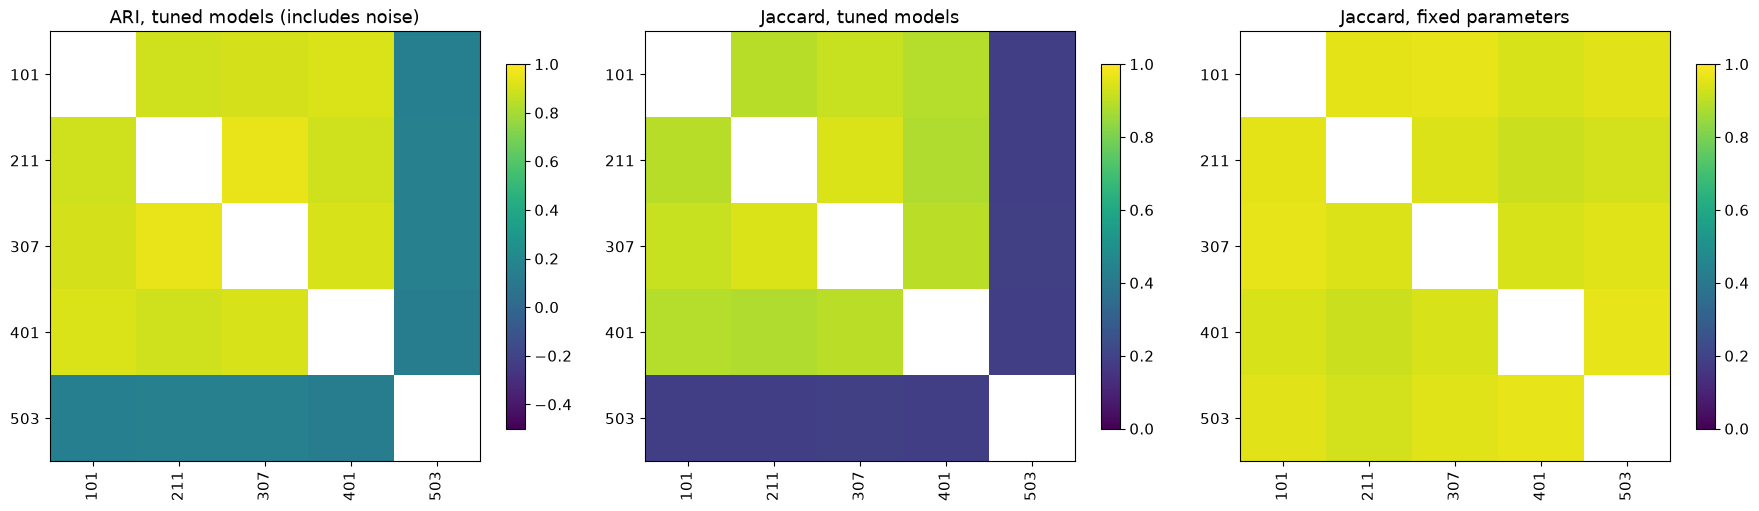

In [20]:
successful_seeds = sorted(runs)
tuned_pairs = compare_runs(runs)
display(tuned_pairs.round(4))

selected_parameters = np.array([[runs[s]["best"]["eps"], runs[s]["best"]["min_samples"]]
                                for s in successful_seeds], dtype=float)
log_parameters = np.log(selected_parameters)
parameter_distance = np.linalg.norm(log_parameters - np.median(log_parameters, axis=0), axis=1)
common_parameter_seed = successful_seeds[int(np.argmin(parameter_distance))]
COMMON_EPS = float(runs[common_parameter_seed]["best"]["eps"])
COMMON_MIN_SAMPLES = int(runs[common_parameter_seed]["best"]["min_samples"])
print(f"Fixed-parameter control: eps={COMMON_EPS:.6f}, min_samples={COMMON_MIN_SAMPLES}")

fixed_runs, fixed_stats_rows = {}, []
for seed in SAMPLE_SEEDS:
    ids = sample_indices[seed]
    X = population_scaled.loc[ids].to_numpy()
    edge_count = KDTree(X).query_radius(X, r=COMMON_EPS, count_only=True).sum(dtype=np.int64)
    if int(edge_count) * 24 > DBSCAN_MEMORY_BUDGET:
        fixed_stats_rows.append({"seed": seed, "status": "skipped_memory"})
        continue
    try:
        model = DBSCAN(eps=COMMON_EPS, min_samples=COMMON_MIN_SAMPLES,
                       algorithm="kd_tree", n_jobs=-1).fit(X)
        anchor_labels = project_to_core(model, anchor_X)
        fixed_runs[seed] = {"ids": ids, "labels": model.labels_.astype(np.int32),
                            "anchor_labels": anchor_labels}
        fixed_stats_rows.append({"seed": seed, "status": "success",
                                **evaluate(model.labels_, compute_score=False),
                                "anchor_coverage": float((anchor_labels >= 0).mean())})
    except (ValueError, MemoryError) as exc:
        fixed_stats_rows.append({"seed": seed, "status": "failed", "reason": str(exc)})
fixed_stats = pd.DataFrame(fixed_stats_rows).set_index("seed")
if "n_clusters" not in fixed_stats:
    fixed_stats["n_clusters"] = np.nan
display(fixed_stats)
fixed_pairs = compare_runs(fixed_runs) if len(fixed_runs) >= 2 else pd.DataFrame()
display(fixed_pairs.round(4))

tuned_jaccard = similarity_matrix(tuned_pairs, "anchor_cluster_jaccard", successful_seeds)
tuned_ari = similarity_matrix(tuned_pairs, "anchor_ARI_all", successful_seeds)
fixed_jaccard = similarity_matrix(fixed_pairs, "anchor_cluster_jaccard", successful_seeds)
overlap_jaccard = similarity_matrix(tuned_pairs, "overlap_cluster_jaccard", successful_seeds)
fixed_overlap_jaccard = similarity_matrix(fixed_pairs, "overlap_cluster_jaccard", successful_seeds)
both_fraction = similarity_matrix(tuned_pairs, "anchor_both_assigned_fraction", successful_seeds)
representative_seeds = [s for s in successful_seeds if representation_table.loc[s, "representative"]]

sample_rows = []
for seed in successful_seeds:
    run = runs[seed]
    peers = [s for s in representative_seeds if s != seed]
    def mean_with_peers(matrix):
        return float(matrix.loc[seed, peers].mean()) if peers else np.nan
    sample_rows.append({"seed": seed, **run["best"],
                        "anchor_coverage": run["anchor_coverage"],
                        "anchor_noise_ratio": run["anchor_noise_ratio"],
                        "anchor_ambiguity_ratio": run["anchor_ambiguity_ratio"],
                        "mean_jaccard_all_successful": mean_to_others(tuned_jaccard).loc[seed],
                        "mean_jaccard_to_peers": mean_with_peers(tuned_jaccard),
                        "mean_fixed_jaccard_to_peers": mean_with_peers(fixed_jaccard),
                        "mean_overlap_jaccard_to_peers": mean_with_peers(overlap_jaccard),
                        "mean_fixed_overlap_jaccard_to_peers": mean_with_peers(fixed_overlap_jaccard),
                        "mean_both_assigned_fraction": mean_with_peers(both_fraction)})
sample_comparison = pd.DataFrame(sample_rows).set_index("seed").join(representation_table)
# A high surrogate score alone cannot hide unstable actual DBSCAN labels on shared training rows.
consensus_columns = ["mean_jaccard_to_peers", "mean_fixed_jaccard_to_peers",
                     "mean_overlap_jaccard_to_peers", "mean_fixed_overlap_jaccard_to_peers"]
sample_comparison["consensus_score"] = sample_comparison[consensus_columns].min(axis=1, skipna=False)
display(sample_comparison.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, matrix, title in zip(axes, [tuned_ari, tuned_jaccard, fixed_jaccard],
                              ["ARI, tuned models (includes noise)", "Jaccard, tuned models",
                               "Jaccard, fixed parameters"]):
    # کپی مستقل و قابل‌نوشتن برای رسم نمودار
    plotted = matrix.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(plotted, np.nan)
    im = ax.imshow(plotted, vmin=(-0.5 if "ARI" in title else 0), vmax=1, cmap="viridis")
    ax.set_xticks(range(len(successful_seeds)))
    ax.set_yticks(range(len(successful_seeds)))
    ax.set_xticklabels(successful_seeds, rotation=90)
    ax.set_yticklabels(successful_seeds)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## سلول ۱۱ — انتخاب نمونهٔ مرکزی، نماینده و باکیفیت

ابتدا نمونه‌های فاقد نمایندگی، پوشش کافی anchor، کیفیت و پایداری کنار گذاشته می‌شوند.
برای هر نمونه، میانگین Jaccard با سایر نمونه‌های نمایندهٔ موفق محاسبه می‌شود؛ قطر ماتریس در میانگین دخیل نیست.
`consensus_score` حداقلِ چهار میانگین است: مدل تنظیم‌شده/ثابت × anchor/اشتراک آموزش.
نمونهٔ دارای بیشترین این امتیاز، نمونهٔ مرکزی یا **medoid عملی** است؛ میانگین شمارهٔ خوشه‌ها محاسبه نمی‌شود.

از نمونه‌هایی که حداکثر ۰٫۰۳ از بهترین اجماعِ قابل‌قبول فاصله دارند، با این وزن‌های ازپیش‌تعیین‌شده انتخاب می‌کنیم:

`final_score = 0.50 × consensus_score + 0.30 × representativeness_score + 0.20 × selection_score`

این وزن‌ها سلیقهٔ تحلیلی‌اند؛ برای نتیجه‌گیری مهم، حساسیت انتخاب به وزن‌ها را هم بررسی کنید.
اگر حداقل ۸۰٪ نمونه‌ها جست‌وجوی موفق نداشته باشند یا اکثریت نمونه‌های نماینده و موفق
شرایط کیفیت/پایداری را نداشته باشند یا کنترل ثابت سه خوشه را غالباً حفظ نکند،
**انتخاب معتبر متوقف می‌شود**؛ یک بهترینِ نامطمئن به‌عنوان نماینده اعلام نمی‌شود.
در چنین شرایطی جدول‌ها را بررسی کنید: پارامترها، فرض سه‌خوشه‌ای، اندازهٔ نمونه یا تعریف جامعه ممکن است نیاز به بازنگری داشته باشد.

,representative,silhouette,stability,consensus_score,representativeness_score,final_score,eligible
seed,,,,,,,
307,True,0.3066,0.8196,0.7351,0.7207,0.7203,True
401,True,0.3211,0.8227,0.7117,0.7289,0.7094,True
101,True,0.3447,0.7981,0.7194,0.6163,0.6823,True
211,True,0.3225,0.8785,0.7259,0.5508,0.6679,True
503,True,0.1702,0.9101,0.1860,0.5882,0.3904,False


Search success: 100%; fixed control success: 100%; fixed three-cluster retention: 100%
Eligible samples: 4; required representative majority: 3
Consensus medoid seed: 307; selected seed: 307


seed,307
eps,0.478522
min_samples,390.0
n_clusters,3.0
noise_ratio,0.370533
smallest_share,0.064667
largest_assigned_share,0.723152
balance,0.703197
silhouette,0.306582
silhouette_std,0.002417
worst_cluster_silhouette,0.205625


,feature,population_mean,sample_mean,abs_smd,ks,wasserstein_sd,quantile_error_sd
0,utm_x,5.348123e+05,5.348763e+05,0.0084,0.0085,0.0100,0.0164
1,utm_y,3.952882e+06,3.952888e+06,0.0011,0.0038,0.0066,0.0203
2,log_price,2.266100e+01,2.265810e+01,0.0032,0.0042,0.0072,0.0166
3,price_value,1.105124e+10,1.089911e+10,0.0089,0.0042,0.0094,0.0291


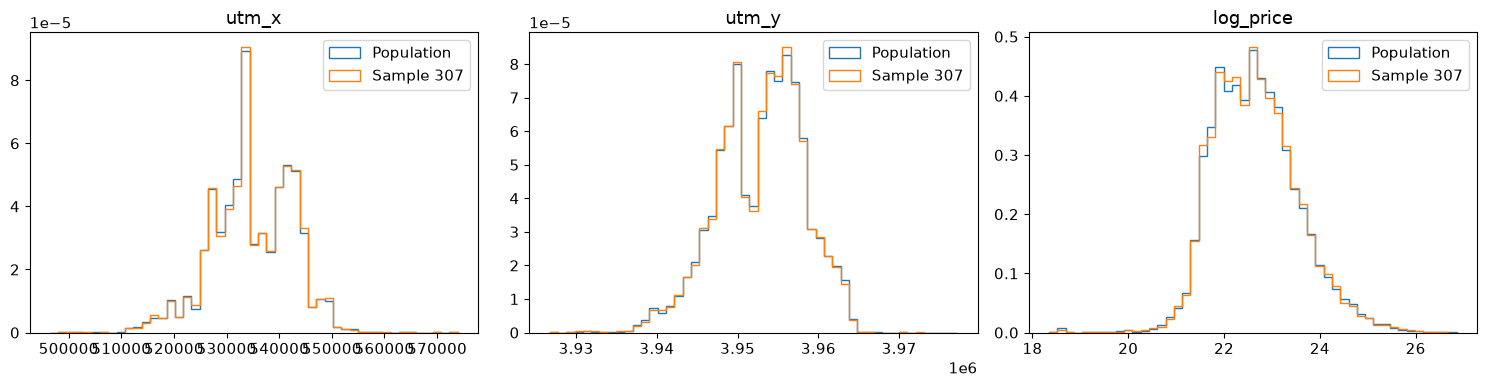

In [21]:
sample_comparison["eligible"] = (
    sample_comparison.representative
    & (sample_comparison.silhouette >= MIN_SILHOUETTE)
    & (sample_comparison.stability >= MIN_LOCAL_STABILITY)
    & (sample_comparison.three_cluster_retention >= MIN_THREE_RETENTION)
    & (sample_comparison.anchor_coverage >= MIN_ANCHOR_COVERAGE)
    & (sample_comparison.mean_both_assigned_fraction >= MIN_PAIR_SHARED_ASSIGNED)
    & (sample_comparison.consensus_score >= MIN_MEAN_JACCARD)
    & sample_comparison[consensus_columns].notna().all(axis=1)
)
sample_comparison["final_score"] = (
    0.50 * sample_comparison.consensus_score
    + 0.30 * sample_comparison.representativeness_score
    + 0.20 * sample_comparison.selection_score
)
success_rate = len(runs) / len(SAMPLE_SEEDS)
fixed_success_rate = len(fixed_runs) / len(SAMPLE_SEEDS)
fixed_three_retention = float((fixed_stats.n_clusters == 3).sum() / len(SAMPLE_SEEDS))
eligible_count = int(sample_comparison.eligible.sum())
required_majority = max(MIN_SUCCESSFUL_SAMPLES, len(representative_seeds) // 2 + 1)
display(sample_comparison[["representative", "silhouette", "stability", "consensus_score",
                           "representativeness_score", "final_score", "eligible"]]
        .sort_values("final_score", ascending=False).round(4))
print(f"Search success: {success_rate:.0%}; fixed control success: {fixed_success_rate:.0%}; "
      f"fixed three-cluster retention: {fixed_three_retention:.0%}")
print(f"Eligible samples: {eligible_count}; required representative majority: {required_majority}")

selected_seed = None
selection_validated = False
if (success_rate < MIN_SUCCESS_RATE or fixed_success_rate < MIN_SUCCESS_RATE
        or fixed_three_retention < MIN_THREE_RETENTION or eligible_count < required_majority):
    raise RuntimeError("No defensible representative selection under the stated thresholds. "
                       "Inspect sample_status, representation_table, sample_comparison and fixed_stats.")

eligible = sample_comparison.loc[sample_comparison.eligible].copy()
best_consensus = eligible.consensus_score.max()
near_consensus = eligible.loc[eligible.consensus_score >= best_consensus - CONSENSUS_TOLERANCE]
selected_seed = int(near_consensus.sort_values(["final_score", "consensus_score"],
                                              ascending=False).index[0])
consensus_medoid_seed = int(eligible.consensus_score.idxmax())
selected_run = runs[selected_seed]
selected_ids = selected_run["ids"]
clean = population.loc[selected_ids].copy()
model_data = population_scaled.loc[selected_ids].copy()
X = model_data.to_numpy()
best = pd.Series(selected_run["best"])
best_eps, best_min_samples = float(best.eps), int(best.min_samples)
labels = selected_run["labels"].copy()
results = selected_run["search_results"].copy()
checks = selected_run["checks"].copy()
assert len(clean) == 15_000
assert len(np.unique(labels[labels >= 0])) == 3
print(f"Consensus medoid seed: {consensus_medoid_seed}; selected seed: {selected_seed}")
display(sample_comparison.loc[[selected_seed]].T)
display(representation_details[selected_seed].round(4))

# Visual population-vs-selected comparison: same axes and bins.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for feature, ax in zip(features, axes):
    bins = np.linspace(population[feature].min(), population[feature].max(), 50)
    ax.hist(population[feature], bins=bins, density=True, histtype="step", label="Population")
    ax.hist(clean[feature], bins=bins, density=True, histtype="step", label=f"Sample {selected_seed}")
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

## سلول ۱۲ — بررسی پس از انتخاب روی audit مستقل

تا اینجا `audit` در انتخاب seed و پارامترها استفاده نشده است. مدل‌های ذخیره‌شده فقط روی این نقاط
انتساب تقریبی می‌دهند و مقایسه می‌شوند؛ fit تازه روی audit انجام نمی‌شود.
این بررسی، احتمال انتخاب خوش‌شانس بر مبنای anchor را کمتر می‌کند اما اثبات تعمیم به جامعه‌ای دیگر نیست.
اگر این بررسی رد شود، خروجی seed همچنان برای بررسی در دسترس است ولی `selection_validated=False`
می‌ماند و سلول‌های خروجی نهایی متوقف می‌شوند. برای انتخاب seed دیگری از همان audit استفاده نکنید؛
در صورت بازطراحی، آن را دادهٔ اکتشافی حساب کنید و مجموعهٔ تازه‌ای برای تأیید کنار بگذارید.

In [22]:
def project_saved_run(run, points):
    # Reuse saved core points without fitting on the population or on either holdout.
    proxy = type("CoreModel", (), {})()
    proxy.eps = float(run["best"]["eps"])
    proxy.components_ = run["core_points"]
    proxy.core_sample_indices_ = np.arange(len(proxy.components_))
    proxy.labels_ = run["core_labels"]
    return project_to_core(proxy, points)

audit_projection = {seed: project_saved_run(run, audit_X) for seed, run in runs.items()}
audit_rows = []
for seed in representative_seeds:
    if seed != selected_seed:
        audit_rows.append({"peer_seed": seed,
                           **partition_metrics(audit_projection[selected_seed], audit_projection[seed])})
audit_comparison = pd.DataFrame(audit_rows).set_index("peer_seed")
display(audit_comparison.round(4))
audit_coverage = float((audit_projection[selected_seed] >= 0).mean())
audit_mean_jaccard = float(audit_comparison.cluster_jaccard.mean())
audit_mean_shared = float(audit_comparison.both_assigned_fraction.mean())
selection_validated = bool(audit_coverage >= MIN_ANCHOR_COVERAGE
                           and audit_mean_jaccard >= MIN_MEAN_JACCARD
                           and audit_mean_shared >= MIN_PAIR_SHARED_ASSIGNED)
print(f"Audit coverage={audit_coverage:.1%}; mean Jaccard={audit_mean_jaccard:.3f}; "
      f"mean shared assigned={audit_mean_shared:.1%}; validated={selection_validated}")
if not selection_validated:
    raise RuntimeError("The selected sample did not pass the separate audit. "
                       "Treat the selection as provisional; review stability before drawing conclusions.")

,n_points,n_compared,n_both_assigned,compared_fraction,both_assigned_fraction,ARI_all,ARI_both_assigned,cluster_jaccard,noise_jaccard,noise_status_agreement
peer_seed,,,,,,,,,,
101,2000,1996,1238,0.9980,0.6190,0.8902,1.0000,0.9074,0.8879,0.9574
211,2000,1994,1279,0.9970,0.6395,0.9443,1.0000,0.9378,0.9357,0.9769
401,2000,1995,1226,0.9975,0.6130,0.9169,1.0000,0.8956,0.9116,0.9659
503,2000,1993,1276,0.9965,0.6380,0.1785,-0.0069,0.1974,0.4616,0.8063


Audit coverage=64.8%; mean Jaccard=0.735; mean shared assigned=62.7%; validated=True


## سلول ۱۳ — نمودار جست‌وجوی پارامترهای نمونهٔ منتخب

نمودارهای نسخهٔ قبلی اکنون فقط از `search_results` مربوط به **نمونهٔ منتخب** ساخته می‌شوند؛
متغیر `X` نیز به همان نمونه برگردانده شده است.

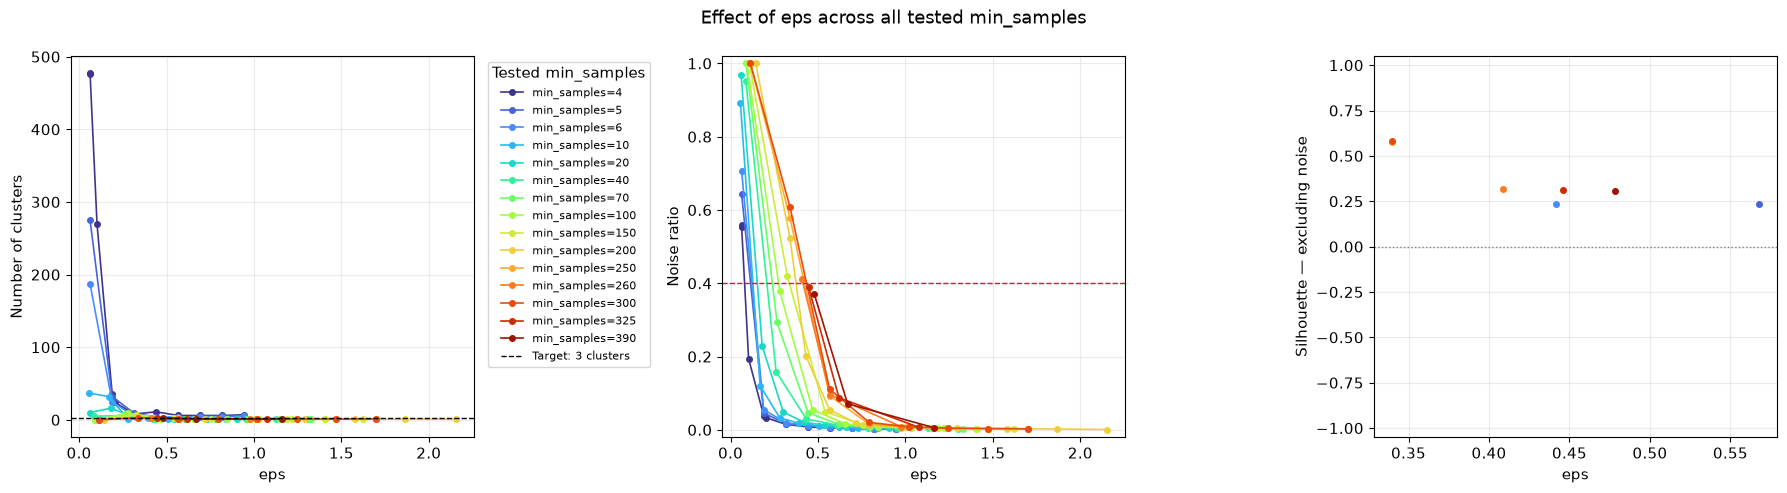

In [23]:
# تنظیمات نمایش
SHOW_OVERVIEW = True
SHOW_PER_MIN_SAMPLES = False

METRICS = [
    ("n_clusters", "Number of clusters"),
    ("noise_ratio", "Noise ratio"),
    ("silhouette", "Silhouette — excluding noise")
]

# استفاده از تمام اجراهای ثبت‌شده، بدون فیلتر کیفیت
# نتایج جست‌وجوی نمونهٔ منتخب در results موجود است.
if not selection_validated:
    raise RuntimeError("Run selection and audit successfully before plotting final results.")
plot_results = results.copy()

if plot_results.empty:
    raise ValueError("No executed models are available to plot.")

plot_results = plot_results.sort_values(
    ["min_samples", "eps"]
)

groups = list(plot_results.groupby("min_samples"))

colors = plt.cm.turbo(
    np.linspace(0.05, 0.95, len(groups))
)


def configure_axes(axes):
    for ax, (_, ylabel) in zip(axes, METRICS):
        ax.set_xlabel("eps")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)

    # تعداد خوشه هدف
    axes[0].axhline(
        3,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Target: 3 clusters"
    )

    # آستانه نویز مجاز
    axes[1].axhline(
        MAX_NOISE,
        color="crimson",
        linestyle="--",
        linewidth=1,
        label=f"MAX_NOISE = {MAX_NOISE:.0%}"
    )
    axes[1].set_ylim(-0.02, 1.02)

    # مرجع صفر برای Silhouette
    axes[2].axhline(
        0,
        color="gray",
        linestyle=":",
        linewidth=1
    )
    axes[2].set_ylim(-1.05, 1.05)


# --------------------------------------------------
# نمودار کلی: مقایسه تمام min_samplesها
# --------------------------------------------------
if SHOW_OVERVIEW:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for (m, group), color in zip(groups, colors):
        for ax, (column, _) in zip(axes, METRICS):
            ax.plot(
                group["eps"],
                group[column],
                marker="o",
                markersize=4,
                linewidth=1.2,
                color=color,
                label=f"min_samples={m}"
            )

    configure_axes(axes)

    axes[0].legend(
        title="Tested min_samples",
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    fig.suptitle("Effect of eps across all tested min_samples")
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# نمودار مستقل برای هر min_samples
# --------------------------------------------------
if SHOW_PER_MIN_SAMPLES:
    for (m, group), color in zip(groups, colors):
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        accepted = quality_mask(group)
        valid_models = group.loc[accepted]

        for ax, (column, _) in zip(axes, METRICS):
            # تمام epsهای اجراشده برای این min_samples
            ax.plot(
                group["eps"],
                group[column],
                marker="o",
                markersize=5,
                linewidth=1.5,
                color=color,
                label="Executed models"
            )

            # مدل‌هایی که هر چهار شرط کیفیت را دارند
            if not valid_models.empty:
                ax.scatter(
                    valid_models["eps"],
                    valid_models[column],
                    marker="*",
                    s=180,
                    color="limegreen",
                    edgecolors="black",
                    zorder=5,
                    label="All 4 conditions met"
                )

            # اگر نقاط کم باشند، تمام epsها روی محور نمایش داده شوند.
            if group["eps"].nunique() <= 12:
                ax.set_xticks(group["eps"].to_numpy())
                ax.tick_params(axis="x", rotation=45)

        configure_axes(axes)

        axes[0].legend(fontsize=8)
        axes[1].legend(fontsize=8)

        fig.suptitle(
            f"min_samples = {m} | "
            f"tested eps = {group['eps'].nunique()} | "
            f"accepted models = {len(valid_models)}"
        )

        plt.tight_layout()
        plt.show()

## سلول ۱۴ — حساسیت پارامترهای نمونهٔ منتخب

بررسی ±۵٪ (یا نزدیک‌ترین عدد صحیح متفاوت برای min_samples کوچک) مربوط به نمونهٔ منتخب است؛
سه خوشه و عضویت نقاط باید نسبت به تغییر کوچک پارامترها پایدار بمانند.

In [24]:
if not selection_validated:
    raise RuntimeError("Selection has not passed audit.")
display(checks)
print(f"Mean local cluster Jaccard: {best.stability:.3f}")
print(f"Three-cluster retention under perturbation: {best.three_cluster_retention:.0%}")

,eps,min_samples,n_clusters,noise_ratio,smallest_share,largest_assigned_share,balance,silhouette,silhouette_std,worst_cluster_silhouette,ARI_to_selected,cluster_jaccard
0,0.454596,390,3,0.430733,0.050600,0.751610,0.657695,NaN,NaN,NaN,0.837986,0.844787
1,0.502448,390,2,0.294867,0.077867,0.889572,0.501206,NaN,NaN,NaN,0.559880,0.517680
2,0.478522,370,3,0.350867,0.069267,0.715826,0.714468,NaN,NaN,NaN,0.945815,0.949271
3,0.478522,410,3,0.386600,0.062667,0.726878,0.698058,NaN,NaN,NaN,0.952878,0.966483


Mean local cluster Jaccard: 0.820
Three-cluster retention under perturbation: 75%


## سلول ۱۵ — خلاصهٔ خوشه‌ها روی ۱۵٬۰۰۰ ردیف منتخب

خلاصه فقط برای نمونهٔ منتخب است؛ ردیف‌های دیگر جامعه برچسب نهایی DBSCAN ندارند.
قیمت اصلی و log_price جدا هستند؛ میانگین/میانهٔ قیمت در واحد اصلی فایل گزارش می‌شوند.

In [25]:
if not selection_validated:
    raise RuntimeError("Selection has not passed audit.")
clustered = clean.copy()
clustered["transformed_price_value"] = model_data["transformed_price_value"]
clustered["cluster"] = labels
members = clustered.loc[clustered["cluster"] != -1]
summary = members.groupby("cluster").agg(
    count=("price_value", "size"),
    median_price=("price_value", "median"),
    mean_price=("price_value", "mean"),
    median_easting=("utm_x", "median"),
    median_northing=("utm_y", "median")
)
summary["share_of_selected_sample"] = summary["count"] / len(clustered)
centers = members.groupby("cluster")[["utm_x", "utm_y", "transformed_price_value"]].mean()
display(summary)
display(centers)
print("Noise fraction:", (labels == -1).mean())
clustered.index.name = "row_id"
print(f"Selected seed={selected_seed}; sample size={len(clustered):,}")

,count,median_price,mean_price,median_easting,median_northing,share_of_selected_sample
cluster,,,,,,
0,6828,5.800000e+09,6.807058e+09,531906.920165,3.951006e+06,0.455200
1,1644,4.900000e+09,5.213909e+09,542519.447773,3.952862e+06,0.109600
2,970,1.800000e+10,1.908600e+10,540902.953566,3.958473e+06,0.064667


,utm_x,utm_y,transformed_price_value
cluster,,,
0,531314.722069,3.951877e+06,-0.224520
1,542659.726750,3.952690e+06,-0.395857
2,540978.685691,3.958810e+06,1.080460


Noise fraction: 0.3705333333333333
Selected seed=307; sample size=15,000


## سلول ۱۶ — نمایش مکانی و سه‌بعدی خوشه‌های منتخب

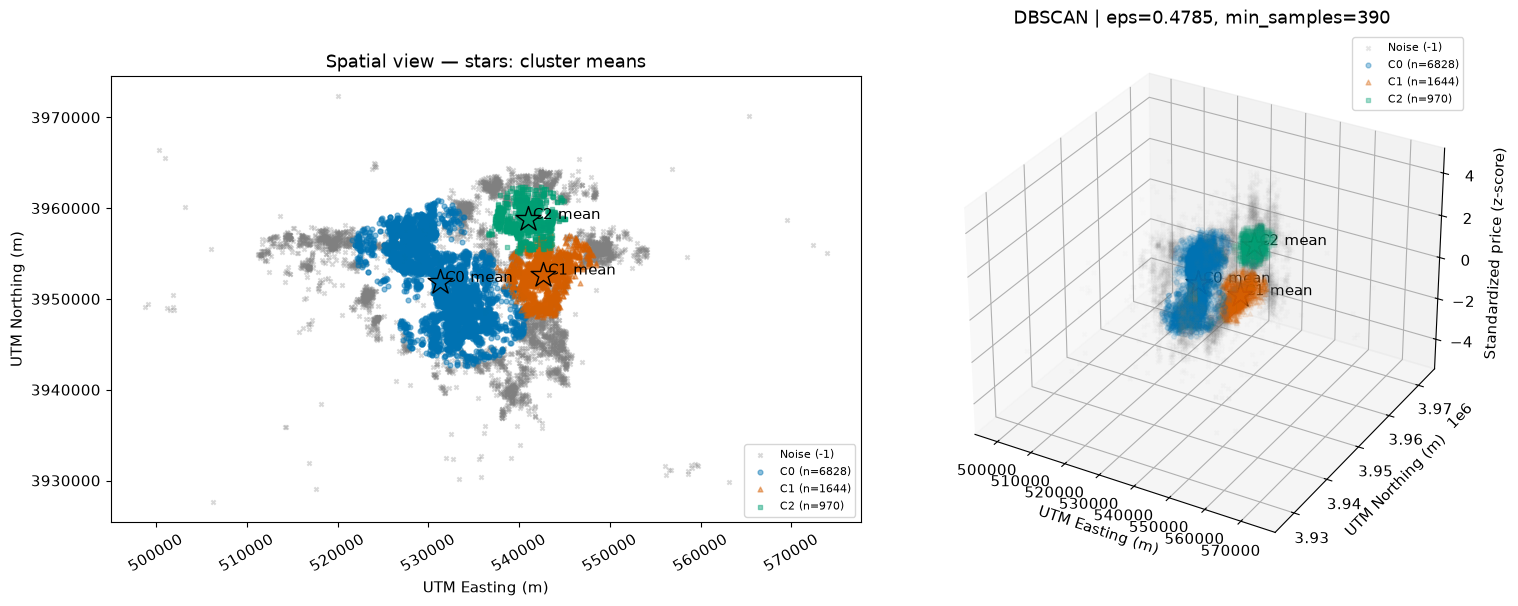

In [26]:
colors = ["#0072B2", "#D55E00", "#009E73"]
markers = ["o", "^", "s"]
fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection="3d")
noise = clustered.loc[clustered["cluster"] == -1]
ax1.scatter(noise.utm_x, noise.utm_y, c="gray", marker="x", s=9, alpha=0.3, label="Noise (-1)")
ax2.scatter(noise.utm_x, noise.utm_y, noise.transformed_price_value,
            c="gray", marker="x", s=9, alpha=0.2, label="Noise (-1)")

for k, color, marker in zip(sorted(members["cluster"].unique()), colors, markers):
    group = members.loc[members["cluster"] == k]
    center = centers.loc[k]
    label = f"C{k} (n={len(group)})"
    ax1.scatter(group.utm_x, group.utm_y, c=color, marker=marker, s=12, alpha=0.45, label=label)
    ax2.scatter(group.utm_x, group.utm_y, group.transformed_price_value,
                c=color, marker=marker, s=12, alpha=0.35, label=label)
    ax1.scatter(center.utm_x, center.utm_y, c=color, marker="*", s=350, edgecolors="black", zorder=5)
    ax2.scatter(center.utm_x, center.utm_y, center.transformed_price_value,
                c=color, marker="*", s=350, edgecolors="black", depthshade=False)
    ax1.annotate(f" C{k} mean", (center.utm_x, center.utm_y))
    ax2.text(center.utm_x, center.utm_y, center.transformed_price_value, f" C{k} mean")

for ax in [ax1, ax2]:
    ax.set_xlabel("UTM Easting (m)")
    ax.set_ylabel("UTM Northing (m)")
    ax.legend(fontsize=8)
ax1.set_aspect("equal", adjustable="box")
ax1.ticklabel_format(style="plain", useOffset=False)
ax1.tick_params(axis="x", rotation=30)
ax1.set_title("Spatial view — stars: cluster means")
ax2.set_zlabel("Standardized price (z-score)")
ax2.set_title(f"DBSCAN | eps={best_eps:.4f}, min_samples={best_min_samples}")
plt.tight_layout()
plt.show()

## سلول ۱۷ — تفاوت قیمت خوشه‌ها

نمودار از قیمت اصلی استفاده می‌کند. چون قیمت یکی از ویژگی‌های خوشه‌بندی است، تفاوت قیمت بین خوشه‌ها
شاهدی مستقل برای درستی مدل یا رابطهٔ علّی نیست.

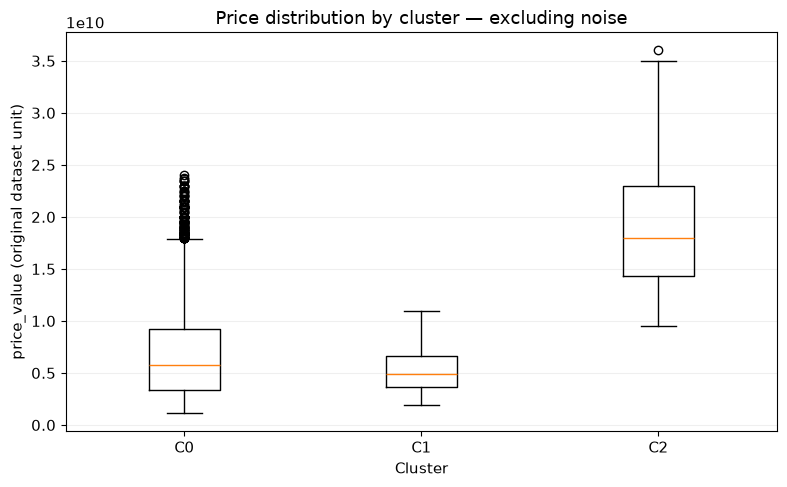

In [27]:
groups = sorted(members["cluster"].unique())
plt.figure(figsize=(8, 5))
plt.boxplot([members.loc[members["cluster"] == k, "price_value"].to_numpy() for k in groups])
plt.xticks(range(1, len(groups) + 1), [f"C{k}" for k in groups])
plt.xlabel("Cluster")
plt.ylabel("price_value (original dataset unit)")
plt.title("Price distribution by cluster — excluding noise")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## سلول ۱۸ — ذخیرهٔ نتایج اجرای شما (اختیاری)

با `SAVE_RESULTS=True`، شناسه‌های نمونهٔ منتخب، برچسب‌ها، مقایسهٔ نمونه‌ها، وضعیت شکست‌ها و
جداول جفتی در پوشهٔ `dbscan_sampling_results` کنار محل اجرای نوت‌بوک ذخیره می‌شوند.
این فایل‌ها فقط پس از اجرای موفق روی CSV واقعی ساخته می‌شوند و همراه این نوت‌بوک نتیجهٔ واقعی از پیش وجود ندارد.

In [28]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    if not selection_validated:
        raise RuntimeError("Only a validated selection can be exported as the final result.")
    output_dir = Path("dbscan_sampling_results")
    output_dir.mkdir(parents=True, exist_ok=True)
    clustered.to_csv(output_dir / "selected_sample_clusters.csv", index=True)
    sample_comparison.to_csv(output_dir / "sample_comparison.csv", index=True)
    representation_table.to_csv(output_dir / "representation.csv", index=True)
    sample_status.to_csv(output_dir / "sample_status.csv", index=True)
    tuned_pairs.to_csv(output_dir / "tuned_pairwise_comparison.csv", index=False)
    fixed_pairs.to_csv(output_dir / "fixed_pairwise_comparison.csv", index=False)
    fixed_stats.to_csv(output_dir / "fixed_parameter_results.csv", index=True)
    audit_comparison.to_csv(output_dir / "audit_comparison.csv", index=True)
    import json
    configuration = {"sample_size": SAMPLE_SIZE, "sample_seeds": SAMPLE_SEEDS,
                     "split_seed": SPLIT_SEED, "population_rows": len(population),
                     "anchor_size": ANCHOR_SIZE, "audit_size": AUDIT_SIZE,
                     "representation_limits": REP_LIMITS, "selected_seed": selected_seed,
                     "selected_eps": best_eps, "selected_min_samples": best_min_samples,
                     "common_eps": COMMON_EPS, "common_min_samples": COMMON_MIN_SAMPLES,
                     "selection_validated": selection_validated,
                     "min_success_rate": MIN_SUCCESS_RATE, "min_mean_jaccard": MIN_MEAN_JACCARD,
                     "consensus_tolerance": CONSENSUS_TOLERANCE,
                     "score_weights": {"consensus": 0.5, "representation": 0.3, "quality": 0.2},
                     "features": features, "scaler_mean": scaler.mean_.tolist(),
                     "scaler_scale": scaler.scale_.tolist()}
    (output_dir / "configuration.json").write_text(json.dumps(configuration, indent=2), encoding="utf-8")
    print(f"Saved results to {output_dir.resolve()}")

### چگونه نتیجه را تفسیر کنیم؟

- اختلاف‌های کوچک با جامعه **و** شباهت بالا بین نمونه‌ها شاهدی به نفع نمایندگی و پایداری‌اند؛ هیچ‌یک به‌تنهایی اثبات نیست.
- نمودارهای heatmap باید در خارج قطر عمدتاً مقادیر بالا داشته باشند، نه فقط یک زیرگروه کوچک با توافق بالا.
- اگر پارامتر ثابت ناپایدار ولی مدل‌های تنظیم‌شده شبیه باشند، نتیجه به تنظیم پارامتر وابسته است؛ این نسخه در انتخاب آن را لحاظ می‌کند.
- اگر مدل‌های تنظیم‌شده هم متفاوت باشند، «نمونه‌ای با بهترین Silhouette» مسئله را حل نمی‌کند.
- اگر حذف IQR یا فیلتر تهران بخش‌های مهمی را کنار گذاشته باشد، نمونهٔ خوبِ جامعهٔ پاک‌شده نمایندهٔ دادهٔ حذف‌شده نیست.
- نمونه‌گیری طبقه‌ای متناسب با مکان/قیمت می‌تواند برای زیرگروه‌های نادر مفید باشد؛ سهم طبقات را حفظ کنید.
  سهم‌دادن برابر به نواحیِ با اندازهٔ متفاوت، تراکم DBSCAN را تغییر می‌دهد و معادل نمونهٔ تصادفی ساده نیست.
- برچسب‌های `anchor`/`audit` تقریبی‌اند؛ برای همین توافق برچسب‌های واقعی روی اشتراک آموزش نیز جداگانه سنجیده شده است.
- انتخاب seed بر مبنای این معیارها اکتشافی است؛ فاصلهٔ اطمینان متعارفِ یک نمونهٔ تصادفی را بی‌بررسی به نمونهٔ انتخاب‌شده نسبت ندهید.

منابع روش:
[DBSCAN و محدودیت Silhouette](https://scikit-learn.org/stable/modules/clustering.html)،
[ARI و استقلال از شمارهٔ خوشه‌ها](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)،
[API مدل DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html).